**Module**: Data 9910 – Working with Data

**Lecturer**: Lucas Rizzo



**Student Details**

- student name = eamonn kelly
- student number = D24127620

ToC - Content Outline

1. Introduction
    1. Project Objective
    1. Data Sources
    1. Issue encountered
1. Part 1 - Import Data, clean and merge to produce working dataframe
    1. 1) Dataset - NASA >  Stellar Hosts     
        1. 1a) Download Stellar Hosts data
        1. 1b) Identify Columns in the data set we wish to retain
        1. 1c) Clean and Aggregate the Stellar Hosts dataset
        1. 1d) Obtain GAIA IDs for use in other downloads
    1. 2) Dataset - PSCompars (pscompars (planetary system composite parameters)= nasa)
        1. 2a) Download the PSCompars dataset
        1. 2b) Remove non-matching 'gaia_dr3_ids' 
        1. 2c) Identify columns in the data we wish to retain and clean data
        1. 2d) Aggregate and Calculate planet level data date for merging with Stellar Host star level dataframe
        1. 2e) Merge 'pscompars' calculated and aggregated per star planetary data into our 'stellar_host_merged_on_gaia' dataframe.
    1. 3) Dataset - GAIA DR3 Astrophysical Parameters (ap)
        1. 3a) Assess the GAIA DR3 dataset before download
        1. 3b) Download the GAIA DR3 Astrophysical parameters and define columns we want data for. 
        1. 3c) Clean GAIA DR3 dataframe
        1. 3d) Merge gaia dataframe into 'stellar_host_psc_df' dataframe
    1. 4) Dataset - Create our Sun dataC
        1. 4a) Identify and calculate appropriate constants and metrics for the Sun
        1. 4b) Create a dataframe for sun data
        1. 4c) Considerations for merging Sun data into main working dataframe 'sh_psc_gaia_df'
1. Part 2 - Explore the working dataframe
    1. 5a) Summmary Statistics
    1. 5b) Visualizations
    1. 5c) Correlations
1. Part 3 - Answer Objective question from our dataframe
    1. 6a) - ? what 
    1. 6a) - is our Sun

## Introduction


### Project Objective

Project Question = *Does the Sun have a twin or a closely related cousin?*

Yhe goal of this project is to see can we determine if there another star in the universe that is identical or similar to our Sun, that we know of and have measurements, metrics for.


### Data Sources
We will use astronmical data from a variety of different public sources. 

1) Stellar Hosts - nasa - one row per star.
    - contains all knwon exoplanet host stars and many parameter values for those stars.
    - Data set taken from >> https://exoplanetarchive.ipac.caltech.edu/  
2) pscompars (planetary system composite parameters)= nasa
    - one row per planet contains star details which are useful so takign and will mergeinto stellar host data
4) GAIA - DR3 - for around 1.46 billion (1.46 109) sources >> https://www.cosmos.esa.int/web/gaia/dr3 
    - Sources in the Gaia Catalogue are all identified through the Gaia Source Identifier, i.e., the source_id field in the various tables in the Gaia Archive > is from Dr3 is different to DR2 etc
   -  3a) 3) I/355/paramsp 'Astrphysical_parameters' - ESA (GAIA) - (1.5 million rows)
    https://www.aanda.org/articles/aa/full_html/2023/06/aa43688-22/aa43688-22.html 
    - this is a subset of calculated data from the DR3 dataset it is a table within the DR3 dataset
    - this is what we will use
4) LAMOST (Large Sky Area Multi object Fiber Spectroscope) - China - https://www.lamost.org/lmusers/user/
    - latest data DR13 requires approval and login
    - DR10 is downloadable - so using that


### Issues encountered
- had problems with gaia IDs and bigint data types, gett exponential numbers,  conversion issues, losing digits. decided to use strings for those 19 digit ID numbers. theyh are also identifies, labels, so not used mathematically, so no calculations use dno them as such string is fine.

- FIT Files as a data source file type - come as indiviaul files, have to be merged standane sets fo data.
- NOTE the datasets are live and do get updated, so where we downlaod in real time, the numnber of rows, columns can change, typically increase when downlaoded at a later date. This might result in differences ni any numbers mentinoed in text or code, depending on when run.numebrs throughoput dependingon when run, f any mentined numbners in dataset are different to what is displayed if ipynb is run at a later date
- data is updated differentyl in different datasets, in some rows are added with partial data and cna have multiple versions of the data, so need to merge on the IDs and select the best option you can, which is hard to determine as no date time stamp. This will reduce give fuller rows of data but.

- accounts
    - ESA > https://psaftp.esac.esa.int/WebInterface/login.html
        -username = ekelly
        - pwd = SlieveMor01!

    - GAIA - catalog sizes  > https://cdn.gea.esac.esa.int/Gaia/gdr3/_catalogue_sizes.txt
    - LAMOST - 

## Part 1

Import the piece/s of data and perform any cleaning and merging to produce a final dataframe

In [1]:
import pandas as pd
import numpy as np
import kagglehub
import re
# esascientific community package for accesing and downloadign data
# https://www.astropy.org/
from astroquery.gaia import Gaia
from astropy.table import Table
# french mirror of thre ea gaia data sets
from astroquery.vizier import Vizier
#impot constant values to sue for sun
from astropy.constants import G, M_sun, R_sun, L_sun
from astropy import units as u

import requests
import time
from bs4 import BeautifulSoup
import json
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#defining global variable path to files and data, it is called thropughout modify this path to match your local path
path = './'

#### 1) Dataset - NASA >  Stellar Hosts

Data set taken from https://exoplanetarchive.ipac.caltech.edu/ 

- This dataset is generated  by the search for exoplanets, so each star will have 0 to > 0 number of planets orbitting it.
- We will download the 'Stellar Hosts' dataset and use it as our primary dataset into which we will merge our other data
- This dataset has 1 row per star, and uses a number of identifiers to track them. We will sue the 'gaia_dr3_id' unique identifier which readily maps into other datasets we will use


##### 1a) Download stallar hosts dataset

In [3]:
# after a bit of playing around tihe the url format we get the url for csv format for the entire stellar hosts dataset
# we download in csv format
# This uses their preferred TAP API, as adql query to directly query the database, and we get it in a clean csv.
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+stellarhosts&format=csv"
stellar_host_df = pd.read_csv(url)

stellar_host_df.shape

# create a lcoal copy in csv as had issue with server going offline and access data. so save lcoal copy in case needed
# wil put a time stampe on the filename for uniqueness
datetime_stamp = datetime.now().strftime("%d%m%y_%H")
sh_csv_file_name = f"{path}stellarhosts_{datetime_stamp}.csv"
stellar_host_df.to_csv(sh_csv_file_name, index=False)
print(f"saved {sh_csv_file_name}")

# NOTE th is nto one row per star >> all sceintific measurements are kept and sources are different, so needs to be filered....
# may add update a paramater, i.e. update mass of a star , added in a new row, old row kept...

saved ./stellarhosts_151225_05.csv


Have a look at downloaded stallar hosts datafram

In [4]:
# check downloadded fine and get feel for shape of data downloaded
# stellar_host_df.head()
# stellar_host_df.describe()
# NOTE te dataset fores get updated, so numnebr of rows can increase if downloaded and affect numebrs throughoput dependingon when run
# Just to be aware if any mentined numbners in dataset are different to what is displayed if ipynb is run at a later date

stellar_host_df.shape

(46892, 136)

1b) Identify Columns in the data set we wish to retain

create a function to scrape the column names, labels and descriptions from website cotaingin a list of parameters

In [5]:
# Create a function to do this as we may need to re-use it
# column mames are abbreviatinos and not very intuitive or human readable
# as such we will  craete a function to scrape the web page for the table column and label anmes
# we want to retain any units and case with thsoe, 
# https://stackoverflow.com/questions/48071598/parsing-through-html-with-beautifulsoup-in-python
def map_col_label_names_to_dict(url,col_map,table_selector="table"):
    response = requests.get(url, timeout=10)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")
    column_defs = []

    tables = soup.select(table_selector)

    for table in tables:
        rows = table.find_all("tr")

        for row in rows:
            cells = row.find_all(["td", "th"])

            # ensure required indices exist
            if len(cells) <= max(col_map.values()):
                continue

            db_col_name = cells[col_map["db_col"]].get_text(strip=True)
            table_label = cells[col_map["label"]].get_text(strip=True)
            description = cells[col_map["description"]].get_text(strip=True)

            # skip headers
            if db_col_name.lower() in {
                "database column name",
                "table label",
                "description",
                "column name"
            }:
                continue

            # remove daggers / footnote markers
            cleaned_db_col = re.sub(r"[†‡*]", "", db_col_name)
            cleaned_db_col = re.sub(r"\s+", "", cleaned_db_col)

            # normalise label
            clean_label = table_label.lower()
            clean_label = re.sub(r"[^a-z0-9_]+", "_", clean_label)
            clean_label = re.sub(r"_+", "_", clean_label).strip("_")

            column_defs.append({
                "db_col_name": cleaned_db_col,
                "label": clean_label,
                "description": description
            })

    return column_defs



run scraping function on stellar data website to get column names and descriptions and put in a dictionary, so cna later merger with other datasets column data and standardise across all datasets. "https://exoplanetarchive.ipac.caltech.edu/docs/API_STELLARHOSTS_columns.html"

In [6]:
# URL for the Stellar Hosts documentation
url = "https://exoplanetarchive.ipac.caltech.edu/docs/API_STELLARHOSTS_columns.html"

# Execute the function
sh_web_col_defs_dict = map_col_label_names_to_dict(url, col_map={'db_col':0, 'label':1, 'description':2})

print("--- quick view of website dictinoary col and description ---")
print(sh_web_col_defs_dict)
print(f" number of key value pairs in column dictionary =  {len(sh_web_col_defs_dict)}")

--- quick view of website dictinoary col and description ---
[{'db_col_name': 'sy_name', 'label': 'system_name', 'description': 'Name of the system star is in'}, {'db_col_name': 'hostname', 'label': 'host_name', 'description': 'Stellar name most commonly used in the literature'}, {'db_col_name': 'hd_name', 'label': 'hd_id', 'description': 'Name of the star as given by the Henry Draper Catalog'}, {'db_col_name': 'hip_name', 'label': 'hip_id', 'description': 'Name of the star as given by the Hipparcos Catalog'}, {'db_col_name': 'tic_id', 'label': 'tic_id', 'description': 'Name of the star as given by the TESS Input Catalog'}, {'db_col_name': 'gaia_dr2_id', 'label': 'gaia_dr2_id', 'description': 'Name of the star as given by the Gaia DR2 Catalog'}, {'db_col_name': 'gaia_dr3_id', 'label': 'gaia_dr3_id', 'description': 'Name of the star as given by the Gaia DR3 Catalog'}, {'db_col_name': 'sy_snum', 'label': 'number_of_stars', 'description': 'Number of gravitationally bound stars in the plan

get a list of actual column mames form the dataframe, thsi is a full list, the webiste only has a subet of coliumn names

In [7]:
# get list of clumns names from dataframe
sh_full_df_cols_list = stellar_host_df.columns
print(f" number of columns in the sh dataframe  = {len(sh_full_df_cols_list)}")
print(f" full dataframe column list = {sh_full_df_cols_list}")

 number of columns in the sh dataframe  = 136
 full dataframe column list = Index(['hostname', 'hd_name', 'hip_name', 'tic_id', 'st_refname', 'sy_refname',
       'ra', 'rastr', 'dec', 'decstr',
       ...
       'sy_kepmag', 'sy_kepmagerr1', 'sy_kepmagerr2', 'st_rotp', 'st_rotperr1',
       'st_rotperr2', 'st_rotplim', 'gaia_dr2_id', 'gaia_dr3_id', 'cb_flag'],
      dtype='object', length=136)


we have 59 rows accounted for in our dictionary. the page we scraped from onyl includes the most relevant or important columns so this is acceptable to us, and the 77 missing columns are related to error values 'err' type column names, or upper and lower limits on data, probability, confidence calculations among other things. On manual exploration of the dataframe and the exoplanet data website, we have what we need in the column dictiionary, but we will further reduce this down to keep our dataset focussed on our objective.

In [8]:
sh_cols_to_keep = ["sy_name","hostname", "hd_name", "hip_name", "tic_id", "gaia_dr2_id", "gaia_dr3_id", "sy_snum", "sy_pnum","sy_mnum", "cb_flag", "st_refname", "st_spectype", "st_teff", "st_rad", "st_mass", "st_met", "st_metratio", 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'st_radv', "ra", "dec", "sy_dist", "sy_kepmag", "sy_gaiamag"]


# checkl the list of column names we created againstt ehncolumn names in thr database to see if they match or not
# so we can compile a list from them and ensure accuracy
sh_valid_cols = [c for c in sh_cols_to_keep if c in stellar_host_df.columns]
sh_missing_cols = [c for c in sh_cols_to_keep if c not in stellar_host_df.columns]

print("Valid columns:", sh_valid_cols)
print("Missing columns:", sh_missing_cols)


stellar_host_df_2 = stellar_host_df[sh_valid_cols].copy()
print(f" shape of new dataframe with only the columns we want to keep  = {stellar_host_df_2}")
stellar_host_df_2.head()

Valid columns: ['sy_name', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'cb_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'st_radv', 'ra', 'dec', 'sy_dist', 'sy_kepmag', 'sy_gaiamag']
Missing columns: []
 shape of new dataframe with only the columns we want to keep  =                    sy_name             hostname hd_name hip_name  \
0               Kepler-936           Kepler-936     NaN      NaN   
1                Kepler-55            Kepler-55     NaN      NaN   
2               Kepler-948           Kepler-948     NaN      NaN   
3               Kepler-917           Kepler-917     NaN      NaN   
4               Kepler-657           Kepler-657     NaN      NaN   
...                    ...                  ...     ...      ...   
46887   KMT-2018-BLG-0748L   KMT-2018-BLG-0748L     NaN      NaN   
46888   KMT-2

,sy_name,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,sy_pnum,sy_mnum,...,st_age,st_dens,st_vsin,st_rotp,st_radv,ra,dec,sy_dist,sy_kepmag,sy_gaiamag
0,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,0.09679,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
1,Kepler-55,Kepler-55,NaN,NaN,TIC 164884002,Gaia DR2 2105930840143687680,Gaia DR3 2105930840143687680,1,5,0,...,NaN,0.02459,NaN,NaN,NaN,285.168329,44.026490,578.796,15.791,15.7813
2,Kepler-948,Kepler-948,NaN,NaN,TIC 138099276,Gaia DR2 2077595394707557120,Gaia DR3 2077595394707557120,1,1,0,...,NaN,1.12282,NaN,NaN,NaN,293.300277,41.523324,868.017,14.800,14.7858
3,Kepler-917,Kepler-917,NaN,NaN,TIC 268383727,Gaia DR2 2085724496490595584,Gaia DR3 2085724496490595584,1,1,0,...,NaN,NaN,NaN,NaN,NaN,299.051256,47.949268,3460.510,15.759,15.8533
4,Kepler-657,Kepler-657,NaN,NaN,TIC 159643991,Gaia DR2 2129158435598210816,Gaia DR3 2129158435598210816,1,1,0,...,NaN,NaN,NaN,NaN,NaN,291.197301,47.307755,1691.880,15.344,15.3190


##### 1c) Clean and Aggregate the Stallar Hosts dataset 

we'll look out for missing values

In [9]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , stellar_host_df_2.shape[0])
print ("Columns  : " , stellar_host_df_2.shape[1])
print('------')
print ("\nFeatures : \n" , stellar_host_df_2.columns.tolist())
print('------')
print ("\nMissing values :  ", stellar_host_df_2.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", stellar_host_df_2.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(stellar_host_df_2.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", stellar_host_df_2.nunique())
print('------')
print('\n null values = ', stellar_host_df_2.isnull().values.any())
print('------')
stellar_host_df_missing = (stellar_host_df_2=='?').sum()
print('\"  ?   \" values present =  \n',stellar_host_df_missing)
print('------')
stellar_host_df_unknown = (stellar_host_df_2=='unknown').sum()
print('\"   unknown   \" values present =  \n',stellar_host_df_unknown)
print('------')
stellar_host_df_na = stellar_host_df_2.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', stellar_host_df_na)
print('------')
stellar_host_df_none = stellar_host_df_2.isin(['None', 'none']).sum()
print('    none    values present = \n', stellar_host_df_none)

Rows     :  46892
Columns  :  30
------

Features : 
 ['sy_name', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'gaia_dr2_id', 'gaia_dr3_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'cb_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'st_radv', 'ra', 'dec', 'sy_dist', 'sy_kepmag', 'sy_gaiamag']
------

Missing values :   481827
------

Missing values per column:   sy_name            0
hostname           0
hd_name        40107
hip_name       39770
tic_id           960
gaia_dr2_id     1425
gaia_dr3_id     1738
sy_snum            0
sy_pnum            0
sy_mnum            0
cb_flag            0
st_refname       170
st_spectype    43500
st_teff         8412
st_rad          8980
st_mass        18218
st_met         23772
st_metratio    23957
st_lum         37828
st_logg        15162
st_age         39142
st_dens        28543
st_vsin        44121
st_rotp        46217
st_radv        44036
ra     

We have a lot of missing data above. This can be fine, as star data is obtained it is added to the dataset, so it is constantly evolving, data is accumulated over time and the dataset being updated as new information and data becomes available over time.

- Missing values 481827 missing values in the whoe dataframe. 
- Duplicates per column: 2948 duplicte entries. There are a lot of duplicates, this is because of hwo data is updated i.e. rows added with some data that was measured, calculated, rather than updatign an existing row, a new row is added with same gaia ID and just the new data, so cna have duplicated. We will address this
- There are no 'none', 'na', 'unknown', '?' , 'null' values, which is a good thing.

Cleaning Actions:
- gaia_dr3_id has 1738 missing cells or empty cells, we will match and merge using this identifier across all our datasets, so as they are empy we will be unable to match the data from them, as such we will remove rows where this column is empty.
- gaia_dr3_id: we will ensure the column is dtype 'str', as we have had issues with 'long', 'bigint' datastypes across datasets. we will sue 'str' as standard for this column across datasets tn sure predictable matching.


Firstly we will try see what the duplicate gaia rows look like, what data they contain, if its all the same, which columns are missing most rows and can we merge column wise, we will just get a sample and lok at that, not all rows 

In [10]:
# pick one valid gaia id row then we'll get all rows that have hat exact Id match
# we'll pick one row that is not NaN using iloc well take the first value index and store that in sample id value
# so we'll get everything for a know valid gaia id
sample_id = stellar_host_df_2["gaia_dr3_id"].dropna().iloc[0]
# quick check on type but it coudl be other dtypes
print(f"sample id stored value is dtype = {type(sample_id)}")
# we'l craete a boolean mask to match true where id matches the sample id
# so we'll get a subset of rows where gaia id is equal to sample id
# if 1 row => its uniqwue id value and if >= 1 row then there are duplicate IDs
stellar_host_df_2[stellar_host_df_2["gaia_dr3_id"] == sample_id]




sample id stored value is dtype = <class 'str'>


,sy_name,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,sy_pnum,sy_mnum,...,st_age,st_dens,st_vsin,st_rotp,st_radv,ra,dec,sy_dist,sy_kepmag,sy_gaiamag
0,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,0.09679,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
7816,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
8902,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,14.00,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
10841,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
11472,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
13482,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,4.40297,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
16464,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,4.40297,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
26599,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,4.57,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
26792,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
31733,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886


this will group by gaia_dr3_id row value then we will see if we merge the rows on gaia_dr3_id what we end up with 

it will leave missing values where the measurement didn't have a value or another measurement

In [11]:
# create subset df and keep rows where gaia_dr3_id == sample_id - if unique has 1 row, if duplicated has > 1 row
# so this only contains gaia ID with >1 rows , so all rows with this ID value
# get all rows for one gaia ID
dups_df = stellar_host_df_2[stellar_host_df_2["gaia_dr3_id"] == sample_id]

# we check the shape, this will have multiple rows as we take a unique gaia ID and checlk the colmns but that gaia ID will ahve multiple rows
# so we have all 12 rows of a unique gaia ID and their column data
dups_df.head()



,sy_name,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,gaia_dr3_id,sy_snum,sy_pnum,sy_mnum,...,st_age,st_dens,st_vsin,st_rotp,st_radv,ra,dec,sy_dist,sy_kepmag,sy_gaiamag
0,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,0.09679,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
7816,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
8902,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,14.0,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
10841,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886
11472,Kepler-936,Kepler-936,NaN,NaN,TIC 270619059,Gaia DR2 2128190453050802048,Gaia DR3 2128190453050802048,1,1,0,...,NaN,NaN,NaN,NaN,NaN,293.577796,46.736295,823.399,14.581,14.7886


In [12]:
# now we check if those columns have data that will conflict i.e. whats the duplication per column in those gaia rows
# raete boolean df True where values are NaN and False where they are contain values, sum the rows column wise, axis =1
# count missing vaues per column in the dup_df rows
# so how manyh missing values does each column have across its rows
dups_df.isna().sum(axis=0)


sy_name         0
hostname        0
hd_name        12
hip_name       12
tic_id          0
gaia_dr2_id     0
gaia_dr3_id     0
sy_snum         0
sy_pnum         0
sy_mnum         0
cb_flag         0
st_refname      0
st_spectype    12
st_teff         1
st_rad          3
st_mass         5
st_met          5
st_metratio     5
st_lum         12
st_logg         3
st_age         10
st_dens         8
st_vsin        12
st_rotp        12
st_radv        12
ra              0
dec             0
sy_dist         0
sy_kepmag       0
sy_gaiamag      0
dtype: int64

In [13]:
# Finally we wil check if those conflicting column values are duplicates. if they are thats a godo thing and we cna compress/merge them without losing any data
# check if these values are duplicates
dups_df.nunique(dropna=True)

sy_name         1
hostname        1
hd_name         0
hip_name        0
tic_id          1
gaia_dr2_id     1
gaia_dr3_id     1
sy_snum         1
sy_pnum         1
sy_mnum         1
cb_flag         1
st_refname     12
st_spectype     0
st_teff         6
st_rad          5
st_mass         4
st_met          4
st_metratio     2
st_lum          0
st_logg         5
st_age          2
st_dens         2
st_vsin         0
st_rotp         0
st_radv         0
ra              1
dec             1
sy_dist         1
sy_kepmag       1
sy_gaiamag      1
dtype: int64

Results of column data merge analysis: 

- Where we have values of '0', all the values are empty, so no issue merging , no data.
- Where we have values of 1, all the duplicate values in that column are duplicates, so we can merge wth no concern at all, we have a lot of these.
- Where we have values > 1, these are different values, and they occur where we woul expect, st_teff(temp), rad, mass, these are calculations, so they will imrpove as better measurements and nroe accurate calculation are made.
- Also columns with 'name' in them, those duplicates we are not concerned about, ie.e. 'st_refname'as they are just repeats of the name in the column, which is fine.

we wil have a further lok at metrics of interest to see if the data diverges a lot or is similar before making a final decision on merging the rows.

pull out the columns of interested from uor sample ID values

In [14]:
dup_df_cols_list = ['st_teff', 'st_rad', 'st_mass', 'st_met','st_age']

cols_values = dups_df[dup_df_cols_list].dropna(how='all')
cols_values
               

,st_teff,st_rad,st_mass,st_met,st_age
0,5610.00,1.171,1.034,0.3800,NaN
7816,5172.88,NaN,NaN,0.1911,NaN
8902,5437.00,0.930,0.822,NaN,14.00
10841,5190.33,NaN,NaN,NaN,NaN
11472,5382.00,1.150,NaN,NaN,NaN
13482,5610.00,1.171,1.034,0.3800,NaN
16464,5610.00,1.171,1.034,0.3800,NaN
26599,5482.00,0.890,0.920,0.0500,4.57
26792,5382.00,1.150,0.970,NaN,NaN
31733,5382.00,1.186,NaN,0.3750,NaN


Create a datafram form it and get some statistical details on the data in those columns

In [15]:
cols_value_df = pd.DataFrame(cols_values)

cols_value_df.describe()

,st_teff,st_rad,st_mass,st_met,st_age
count,11.000000,9.000000,7.000000,7.000000,2.000000
mean,5442.564545,1.110000,0.978286,0.305157,9.285000
std,161.579967,0.114379,0.081963,0.132538,6.668017
min,5172.880000,0.890000,0.822000,0.050000,4.570000
25%,5382.000000,1.150000,0.945000,0.283050,6.927500
50%,5437.000000,1.171000,1.034000,0.380000,9.285000
75%,5610.000000,1.171000,1.034000,0.380000,11.642500
max,5610.000000,1.186000,1.034000,0.380000,14.000000




Conclusion
- from the above t we don't have a lot of duplicate column data, there is some 'hd_name', 'hip_name' (which is expected), but mostly the data is complementary and merging the rows on ID will result in a flattened single, full (ish) row. 
- for numerical data, standard deviation from the data for most values is small but its still present, temp value has biggest spread of data. Again we only done a sample, so could be betere or worse for other rows but is present.
- some outliers so we may choose median as a value imputation choice to remove any excessive values 
    - There is a risk with this, in that the latest measurement could be suing a new methodology and give a starkly different result to previous dat, but it could be the most accurate. This is where my lack of specific domain knowledge may affect the outcome. However the median imputation approach is probably still the most balanced approach.
- From the above is that we don't have a lot of duplicate column data, there is some 'hd_name', 'hip_name' (which is expected), but mostly the data is complementary and merging the rows on ID will result in a flattened single, full (ish) row. 

As a result of the above, we will merge rows on gaia_dr3_id as follows
- categorical and identifier data, we wil take the first non null value
- continous data we wil use a median calculation to mitigate effect of outliers.

Overall, the identical rows together and combine the data cells, so we have a single row per star and maximise the data available for that star.

we will merge all duplicate rows on gaia_dr3_id.

also to note, we don't have a date time stamp to choose from, we do have probability column but taking the first value is a reasonably safe approach for ur purposes.

In [16]:
# will craete a new list here alongside function for clariry an call ths later when runnign function
cat_median_cols_list = ['st_teff', 'st_rad', 'st_mass', 'st_met','st_age']

# Create a function to do the nerge as wil re-use on other datasets
# will define how we meger the columns
def merge_column(x):
    # if all values in column are missing leave missing
    if x.notna().sum() == 0:
        return pd.NA
    
    # if the colimn is in the col list form earlier use the median value from all non null values
    # we'll use thsi approach over dtype identification as some numeric data mau nto be appropriate to use median
    # so just what we specifically define
    if x.name in cat_median_cols_list:
        return x.dropna().median()
    
    # merge takign first value - this is for named text values
    # anythign not in the col list above or not completely missing data
    return x.dropna().iloc[0]




In [17]:
# merge the  duplicate gaia ID rows 
# merge the duplicate values to fill the missing cells - take first non-null vlaue across all duplicated and use that
# grouby by the gaia id and aggregate by column applying lambda to each column
# if missing value take the firstg non-missing value , does anyh value exist, dro the na, take first valid valie index [0],else if all values are missing leave it mising 
# return the gaia id column back to normal column, remove groupby indexiing
# stellar_host_merged_on_gaia = (stellar_host_df_2.groupby("gaia_dr3_id").agg(lambda x: x.dropna().iloc[0] if x.notna().any() else pd.NA).reset_index())

# merge the rows using function
stellar_host_merged_on_gaia = (stellar_host_df_2.groupby("gaia_dr3_id").agg(merge_column).reset_index())

print("number of rows in df before merging on gaia id", len(stellar_host_df_2))
print("number of rows in df after merging on gaia id", len(stellar_host_merged_on_gaia ))
stellar_host_merged_on_gaia.head()


number of rows in df before merging on gaia id 46892
number of rows in df after merging on gaia id 4443


,gaia_dr3_id,sy_name,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,sy_snum,sy_pnum,sy_mnum,...,st_age,st_dens,st_vsin,st_rotp,st_radv,ra,dec,sy_dist,sy_kepmag,sy_gaiamag
0,Gaia DR3 1000423609817438592,TOI-1716,TOI-1716,<NA>,<NA>,TIC 14336130,Gaia DR2 1000423609817438592,1,1,0,...,5.4,0.827,<NA>,<NA>,<NA>,105.083329,56.824194,104.158,<NA>,9.24094
1,Gaia DR3 1003351437484254464,HD 48948,HD 48948,HD 48948,HIP 32769,TIC 88228576,Gaia DR2 1003351437484254464,1,3,0,...,11.48,2.877766,4.0,43.45,-53.0,102.489811,60.337313,16.9043,<NA>,8.11311
2,Gaia DR3 1004358968092652544,6 Lyn,6 Lyn,HD 45410,HIP 31039,TIC 444865362,Gaia DR2 1004358968092652544,1,1,0,...,3.1765,<NA>,1.32,<NA>,39.69716,97.696031,58.161175,54.6599,<NA>,5.60686
3,Gaia DR3 1008018211509401728,HD 40956,HD 40956,HD 40956,HIP 28951,TIC 71099944,Gaia DR2 1008018211509401728,1,1,0,...,1.35,<NA>,2.7,<NA>,-15.28374,91.662802,63.453875,116.593,<NA>,6.14049
4,Gaia DR3 101040381244467968,HD 14067,HD 14067,HD 14067,HIP 10657,TIC 246937460,Gaia DR2 101040381244467968,1,1,0,...,0.69,<NA>,1.0,<NA>,-11.53842,34.293348,23.767655,142.024,<NA>,6.23751


HUgely reduced dataset
each star had approximately 10 entries, so 10 different rows per star, all with different data, resulting in a lot of empty cells.
we now have aggregated one row per giaia_dr3_id, so one row per star with consolidated data, imputed values for specific continuous data and first value for categorical

In [18]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , stellar_host_merged_on_gaia.shape[0])
print ("Columns  : " , stellar_host_merged_on_gaia.shape[1])
print('------')
print ("\nFeatures : \n" , stellar_host_merged_on_gaia.columns.tolist())
print('------')
print ("\nMissing values :  ", stellar_host_merged_on_gaia.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", stellar_host_merged_on_gaia.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(stellar_host_merged_on_gaia.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", stellar_host_merged_on_gaia.nunique())
print('------')
print('\n null values = ', stellar_host_merged_on_gaia.isnull().values.any())
print('------')
stellar_host_df_missing = (stellar_host_merged_on_gaia=='?').sum()
print('\"  ?   \" values present =  \n',stellar_host_df_missing)
print('------')
stellar_host_df_unknown = (stellar_host_merged_on_gaia=='unknown').sum()
print('\"   unknown   \" values present =  \n',stellar_host_df_unknown)
print('------')
stellar_host_df_na = stellar_host_merged_on_gaia.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', stellar_host_df_na)
print('------')
stellar_host_df_none = stellar_host_merged_on_gaia.isin(['None', 'none']).sum()
print('    none    values present = \n', stellar_host_df_none)

Rows     :  4443
Columns  :  30
------

Features : 
 ['gaia_dr3_id', 'sy_name', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'gaia_dr2_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'cb_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'st_radv', 'ra', 'dec', 'sy_dist', 'sy_kepmag', 'sy_gaiamag']
------

Missing values :   24697
------

Missing values per column:   gaia_dr3_id       0
sy_name           0
hostname          0
hd_name        3663
hip_name       3674
tic_id            2
gaia_dr2_id       0
sy_snum           0
sy_pnum           0
sy_mnum           0
cb_flag           0
st_refname       64
st_spectype    2850
st_teff          86
st_rad          106
st_mass          88
st_met          426
st_metratio     432
st_lum          201
st_logg         121
st_age         1003
st_dens         332
st_vsin        2838
st_rotp        3902
st_radv        2753
ra                3
dec           

- number of unique gaia_dr3_id valus =    4443 (whcih matches our dataframe shape i.e.  4443)
- There are no 'none', 'na', 'unknown', '?' values, which is a good thing.
- no duplicates in the dataframe
- no missing 'gaia_dr3_id' values
- missing values - still ahve 24697 , that is fine there will always be missing values. WWill not impute any values as they are missing scientific data which does tno exist or has no measurement for. so no aggregation/calculation is required etc We will also merge with other datasets which which may have measurements for the missing dataset an can populate them on merging.

#### 1d) obtain GAIA IDs for use in other downloads

Need to get the uniqwue values for GAIA_IDs. We will sue those to download other datasets. Other datasets are to big, in TBs in siuze, and this will allow us filter just what we need, reduce downlaod time and make ti more manageable

In [19]:
# get colimns containign the string 'gaia' from the dataframe
# gaia IDs are the column we will merge against and also pivit around across daatsets. This is a unique identifier used by the ESA
# we willa also use gaia ID to filter data we down load from other sources, to limit file size to only relevant data/rows.
gaia_cols = [col for col in stellar_host_merged_on_gaia.columns if'gaia' in col.lower()]

print(f"gaia columns  : {gaia_cols}")

gaia columns  : ['gaia_dr3_id', 'gaia_dr2_id', 'sy_gaiamag']


Check the data format. we will leave as astr object types as convertign to int rounds and we havhe huge 19 digit numbers, we can do string matches across datasets

As per gudielines on ESA site there is no direct relationship between GAIA DR2 IDs and DR3 IDs

Sources in the Gaia Catalogue are all identified through the Gaia Source Identifier, i.e., the source_id field in the various tables in the Gaia Archive. the source list for Gaia DR3 should be treated as independent from Gaia DR2 and from Gaia DR1. With each new Gaia data release, the source list is becoming progressively more stable

Refer to [Gaia Data Release 3 (Gaia DR3)](https://www.cosmos.esa.int/web/gaia/dr3) for details from above amnd futher details re the data set.


In [20]:
stellar_host_merged_on_gaia['gaia_dr3_id'].head(10)

0    Gaia DR3 1000423609817438592
1    Gaia DR3 1003351437484254464
2    Gaia DR3 1004358968092652544
3    Gaia DR3 1008018211509401728
4     Gaia DR3 101040381244467968
5    Gaia DR3 1011435012611767552
6    Gaia DR3 1014520826353577088
7    Gaia DR3 1019003226022657920
8    Gaia DR3 1019003329101872896
9    Gaia DR3 1022456104850892928
Name: gaia_dr3_id, dtype: object

craete a list object into which we'll put these strings, we'll refer to this list when downlaoding other data sources

strip the text and number not needed, so onyl get 19 digit number at the end of string, use regex expressino to filter the cell values

i.e. want to get the GAIA ID numbers minus the prefix strings

Problem
need to match only the gaia IDs numbers so can downlaod only the data we wnat from gaia downlaod
DR3 and DR4 are nto 100% identical m and this is as expected as ID get updated as data is updated sources are split, uydpated data changes thigns etc so it loks like our data is intact and we have ths striped gaiaa ID

In [21]:
# we'll create a copy to work in, keepign our roginal in tac if we need tok revert to it at some stage
stellar_host_merged_on_gaia_2 = stellar_host_merged_on_gaia.copy()

# http://regex101.com
# $ start at the end of thestring, only match the last part,
# smatch 10 to 20 digits in a row, ignore the space, so we don't get the 2 from DR2, so contiguous, between 10 and 20 characters and at the end of the string 
# stop at space
stellar_host_merged_on_gaia_2['gaia_dr3_num'] = stellar_host_merged_on_gaia_2['gaia_dr3_id'].astype(str).str.extract(r'(\d{10,20})', expand=False)

print(stellar_host_merged_on_gaia_2['gaia_dr3_num'].head(10))


# stellar_host_df_2['dr2_equals_dr3'] = stellar_host_df_2['dr2_num'] == stellar_host_df_2['dr3_num']

# stellar_host_df_2 = stellar_host_df_2.dropna(subset=['dr3_num'])stellar_host_df_2['dr2_equals_dr3'].value_counts()

0    1000423609817438592
1    1003351437484254464
2    1004358968092652544
3    1008018211509401728
4     101040381244467968
5    1011435012611767552
6    1014520826353577088
7    1019003226022657920
8    1019003329101872896
9    1022456104850892928
Name: gaia_dr3_num, dtype: object


In [22]:
# check to make sure no duplciates and all unique values
print(f" number of duplicate gaia numeric values = {stellar_host_merged_on_gaia_2["gaia_dr3_num"].duplicated().sum()}")

# we encountered some duplicates in our checks and will pritn them otu to see them now
(stellar_host_merged_on_gaia_2.loc[stellar_host_merged_on_gaia_2["gaia_dr3_num"].duplicated(keep=False), ["gaia_dr3_id", "gaia_dr3_num"]].sort_values("gaia_dr3_num"))


 number of duplicate gaia numeric values = 4


,gaia_dr3_id,gaia_dr3_num
2666,Gaia DR3 2646280705713202816,2646280705713202816
2667,Gaia DR3 2646280705713202816 B,2646280705713202816
2668,Gaia DR3 2646280705713202816 C,2646280705713202816
2863,Gaia DR3 3285426613077584384,3285426613077584384
2864,Gaia DR3 3285426613077584384 C,3285426613077584384
3503,Gaia DR3 4840909492463387136,4840909492463387136
3504,Gaia DR3 4840909492463387136 C,4840909492463387136


Duplicate gaia_id_ids are present due to a suffix added to the id. 

We need a numeric only value as a dataset we will merge with later ha a 'source_id' identifier which is only he numeric part of the 'gaia_dr3_id'. So we need a stripped numeric ID to allow us merge later and must address this here.

In [23]:
dup_rows = (stellar_host_merged_on_gaia_2.loc[stellar_host_merged_on_gaia_2["gaia_dr3_num"].duplicated(keep=False)]
    .sort_values(["gaia_dr3_num", "gaia_dr3_id"])
)

dup_rows


,gaia_dr3_id,sy_name,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,sy_snum,sy_pnum,sy_mnum,...,st_dens,st_vsin,st_rotp,st_radv,ra,dec,sy_dist,sy_kepmag,sy_gaiamag,gaia_dr3_num
2666,Gaia DR3 2646280705713202816,GJ 900,GJ 900 A,<NA>,HIP 116384,TIC 422618003,Gaia DR2 2646280705713202816,3,1,0,...,2.590302,<NA>,11.9,-10.44,353.752618,1.605521,20.8065,<NA>,9.02571,2646280705713202816
2667,Gaia DR3 2646280705713202816 B,GJ 900,GJ 900 B,<NA>,HIP 116384 B,<NA>,Gaia DR2 2646280705713202816 B,3,1,0,...,<NA>,<NA>,<NA>,-10.44,<NA>,<NA>,<NA>,<NA>,<NA>,2646280705713202816
2668,Gaia DR3 2646280705713202816 C,GJ 900,GJ 900 C,<NA>,HIP 116384 C,<NA>,Gaia DR2 2646280705713202816 C,3,1,0,...,<NA>,<NA>,<NA>,-10.44,<NA>,<NA>,<NA>,<NA>,<NA>,2646280705713202816
2863,Gaia DR3 3285426613077584384,HIP 21152,HIP 21152,HD 28736,HIP 21152,TIC 452767166,Gaia DR2 3285426613077584384,2,1,0,...,0.482318,45.6,<NA>,40.6,68.020521,5.410075,43.4073,<NA>,6.25568,3285426613077584384
2864,Gaia DR3 3285426613077584384 C,HIP 21152,HIP 21152 C,<NA>,HIP 21152 C,TIC 452784919,Gaia DR2 3285426613077584384 C,2,1,0,...,<NA>,<NA>,<NA>,<NA>,68.486279,5.623237,<NA>,<NA>,19.9943,3285426613077584384
3503,Gaia DR3 4840909492463387136,HIP 19976,HIP 19976,<NA>,HIP 19976,TIC 7623762,Gaia DR2 4840909492463387136,2,1,0,...,2.050451,<NA>,<NA>,<NA>,64.259788,-40.79852,40.2707,<NA>,9.88841,4840909492463387136
3504,Gaia DR3 4840909492463387136 C,HIP 19976,HIP 19976 C,<NA>,HIP 19976 C,TIC 7623762 C,Gaia DR2 4840909492463387136 C,2,1,0,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4840909492463387136


In [24]:
# get a mising data count per cell for each of the duplicates
# It loks for visible check the suffix ketter rows are missing more data
# If this confirms we wkill remove the ids containing suffix 
dup_missing = (stellar_host_merged_on_gaia_2.loc[stellar_host_merged_on_gaia_2["gaia_dr3_num"].duplicated(keep=False)    ]
    .assign(n_missing=lambda df: df.isna().sum(axis=1)).sort_values(["gaia_dr3_num", "n_missing"])
)

dup_missing[["gaia_dr3_id", "gaia_dr3_num", "n_missing"]]



,gaia_dr3_id,gaia_dr3_num,n_missing
2666,Gaia DR3 2646280705713202816,2646280705713202816,3
2667,Gaia DR3 2646280705713202816 B,2646280705713202816,17
2668,Gaia DR3 2646280705713202816 C,2646280705713202816,17
2863,Gaia DR3 3285426613077584384,3285426613077584384,2
2864,Gaia DR3 3285426613077584384 C,3285426613077584384,14
3503,Gaia DR3 4840909492463387136,4840909492463387136,9
3504,Gaia DR3 4840909492463387136 C,4840909492463387136,18


Given ids contianing letetr suffix have more missing data, we will remove those and keep the other ids with no suffix.
 
here is a lack of domain knowledge as to why they have been added a suffix unfortunately.  But this is probably the best solution can come up with given the time constraints. Given we have a very large number of stars this should not be a statistically effect on our data analysis anyway. 

In [25]:
# remove the duplciate rows keeping rows with no suffix appended ot ther gaiai ids

#regex101.com -we'll sue regex to strip the suffix off the id
gaia_id_with_suffix = stellar_host_merged_on_gaia_2["gaia_dr3_id"].str.contains(r"\s[A-Z]$")

# have a lok at shape befor ehand make sure as we expect
print(f" before shape = {stellar_host_merged_on_gaia_2.shape}")

# I will not create a new dataframe as this is a late correction after issues were identofied during analsis downsrream
# I dont want to have to rename dataframes throughout and ptentially cause more issues, so modifying exising dataframe is the safest option 
# given the timeframe available.
stellar_host_merged_on_gaia_2 = (stellar_host_merged_on_gaia_2.assign(gaia_id_with_suffix=gaia_id_with_suffix)
    .sort_values("gaia_id_with_suffix").drop_duplicates(subset="gaia_dr3_num", keep="first").drop(columns="gaia_id_with_suffix"))


print(f" after shape = {stellar_host_merged_on_gaia_2.shape}")




 before shape = (4443, 31)
 after shape = (4439, 31)


In [26]:
print(f" 'gaia_dr3_num'  contains onyl unique values True  / Fale = {stellar_host_merged_on_gaia_2["gaia_dr3_num"].is_unique}")


 'gaia_dr3_num'  contains onyl unique values True  / Fale = True


we have succesfully addrssed the non duplicate 'gaia_dr3_num' issue, caused by the addition on a suffix on some gaia ids

In [27]:
# now we have an additional column for our 'gaia_dr3_num' values, givign us 31 as opposed to 30 columns, which is as expected
stellar_host_merged_on_gaia_2.shape


(4439, 31)

Check to see fi cell values are as we expect, identify ant problematoc cell data

In [28]:
# check to see if gaia Ids are as we expect and what ros contain data we are not expecting and are problematic
# Convert to string for consistent checks
col = stellar_host_merged_on_gaia_2['gaia_dr3_num'].astype(str)

diagnostics = {
    "total_rows": len(col),

    # Missing or NA-like
    "is_na": col.isna().sum(),
    "empty_string": (col.str.strip() == "").sum(),
    "literal_nan_or_none": col.str.lower().isin(["nan", "none"]).sum(),

    # Invalid characters (non-digits)
    "contains_nondigits": col.str.contains(r"\D", regex=True).sum(),

    # Has a valid digit sequence (extractable)
    "contains_digit_block_10_20": col.str.contains(r"\d{10,20}", regex=True).sum(),

    # Fullmatch valid Gaia ID (exact digits only)
    "valid_fullmatch": col.str.fullmatch(r"\d{10,20}").sum(),

    # Wrong length but digits-only
    "digits_only_wrong_length": (
        col.str.fullmatch(r"\d+").fillna(False) &
        ~col.str.fullmatch(r"\d{10,20}")
    ).sum(),
}

pd.Series(diagnostics)


total_rows                    4439
is_na                            0
empty_string                     0
literal_nan_or_none              0
contains_nondigits               0
contains_digit_block_10_20    4439
valid_fullmatch               4439
digits_only_wrong_length         0
dtype: int64

Remove problematic cells, and ensure shape # of rows matches shape value for rows continaing correct data structure as per earlier diagnosticWoth earlier cleanign - thsi is no longer needed as gaia_dr3_id values are all as expected.

In [29]:
# # remove the probllematic gaia ID rows

# sh_clean_gaiaid_df = stellar_host_df_2[stellar_host_df_2['gaia_dr3_num'].astype(str).str.fullmatch(r'\d{10,20}')].copy()

# #checl rows have been removed
# sh_clean_gaiaid_df.shape

# # sh_clean_gaia_df['dr3_num'].head()

re run disgnostics to verify the changes/deletions - verufying the new dataframe contains only valid gaia IDs and  - and  new df shape is 45132, 137

Create two new list objects 

- one for full gaia ID i.e. alphanumeric
- one for just numerc gaia ID i.e. numeric(prefix stripped out)
 
some data sources will filter off only numeric data and some will filter off fill ID, so just creatign two list objects and we cna use either fir dat download as we need.

In [30]:

sh_clean_gaiaid_fullid_list = stellar_host_merged_on_gaia_2['gaia_dr3_id'].astype(str).tolist()

sh_clean_gaiaid_fullid_list[:3]

['Gaia DR3 1000423609817438592',
 'Gaia DR3 3545653561942122368',
 'Gaia DR3 3545873945303316224']

In [31]:
sh_clean_gaiaid_num_list = stellar_host_merged_on_gaia_2['gaia_dr3_num'].astype(str).tolist()

sh_clean_gaiaid_num_list [:3]

['1000423609817438592', '3545653561942122368', '3545873945303316224']

In [32]:
# Final Stellar Hosts Dataframe - Just printing again here with label as a location marker in the ipynb file...
# stellar_host_merged_on_gaia_2.index
stellar_host_merged_on_gaia_2.shape

(4439, 31)

We end up with 4 objects we wil use later:
 
- 'sh_cols_to_keep ' - list of dataframe column names
- 'sh_clean_gaiaid_fullid_list' - list containing full gaia ID i.e. alphanumeric
- 'sh_clean_gaiaid_num_list' - list containing numeric gaia ID i.e. numeric(prefix stripped out)
- 'stellar_host_merged_on_gaia_2'  - cleaned stellar Hosts dataframe

#### 2) PSCompars (pscompars (planetary system composite parameters)= nasa)

Data set taken from https://exoplanetarchive.ipac.caltech.edu/ 

- This dataset is more based on measurable parameters from stars in planetary systems.
- we can complement the existing stellar hosts dataset with aggregated and calcualted data from this dataset
- It has one rwo per planet, so wil need careful assessment and cleaning to gain our star data from it. enabling a more statistical view of the known exoplanet population and their host environments. 
- This table provides a more complete set of parameters, though not necessarily aligned wth pur one row per start main dataset

https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html 

##### 2a) Download the PSCompars dataset

In [33]:
# downlaod using ADQL and the tap server
# we'll save as csv aswell as have had problems with downtime and maintenance on  servers, and them not being available, so as a backup
# this is the full dataset
url = "https://exoplanetarchive.ipac.caltech.edu/TAP/sync?query=select+*+from+pscomppars&format=csv"
pscompars_df = pd.read_csv(url)

# use dat time stanpe to give us unique id for the csv, so we don't overwirte earlier downlaods
datetime_stamp = datetime.now().strftime("%d%m%y_%H")
pscompars_csv_file_name = f"{path}pscompars_{datetime_stamp}.csv"
pscompars_df.to_csv(pscompars_csv_file_name, index=False)
print(f"saved {pscompars_csv_file_name}")


print(pscompars_df.shape)
#pscompars_df.cols

saved ./pscompars_151225_06.csv
(6061, 683)


2b) Remove non-matching 'gaia_dr3_id' IDs

first step will be just to remove any rows where the gaia_dr3_d does not match a gaia_dr3_id from our exisitng data. As we cannot match it to any stars in our existing dataset, so we will just remove straight away.

In [34]:
# identify the 'gaia' named columns, to see what we have
psc_gaia_cols = [col for col in pscompars_df.columns if'gaia' in col.lower()]

print(f"gaia columns  : {psc_gaia_cols}")

gaia columns  : ['sy_gaiamag', 'sy_gaiamagerr1', 'sy_gaiamagerr2', 'sy_gaiamaglim', 'sy_gaiamagsymerr', 'sy_gaiamagstr', 'sy_gaiamagformat', 'sy_gaiamag_solnid', 'sy_gaiamag_reflink', 'gaia_dr2_id', 'gaia_dr3_id']


In [35]:
# lpok at format of data in pscompars_df['gaia_dr3_id'], check it is as we expect aand we cna use it to match aganst our gaia id list
pscompars_df['gaia_dr3_id'].head(10)

0    Gaia DR3 2086441721667415424
1    Gaia DR3 2052381737659167488
2    Gaia DR3 2100418850915010432
3    Gaia DR3 2078049767888231936
4    Gaia DR3 2136207095405014912
5    Gaia DR3 2101761079737564672
6    Gaia DR3 2126563450717837056
7    Gaia DR3 2051832634677771008
8    Gaia DR3 5902750168276592256
9    Gaia DR3 2080048680026646912
Name: gaia_dr3_id, dtype: object

In [36]:
# check dtypes in pscompars_df["gaia_dr3_id"]  and also sh_clean_gaiaid_fullid_list (a list we created earlier)
# , make sure both are still str values so we cna relaibly mach

# convert the gaia_dr3_id" to str dtype and remove any whitespace at the begining or end fo the string
pscompars_df["gaia_dr3_id"] = (pscompars_df["gaia_dr3_id"].astype(str).str.strip())

# crate new dataframe where the gaia ID is present in the earlier created haia id list
pscompars_gaiaid_df = pscompars_df[pscompars_df["gaia_dr3_id"].isin(sh_clean_gaiaid_fullid_list)].copy()


pscompars_gaiaid_df.shape
list(pscompars_gaiaid_df.columns)




['objectid',
 'pl_name',
 'pl_letter',
 'hostid',
 'hostname',
 'hd_name',
 'hip_name',
 'tic_id',
 'disc_pubdate',
 'disc_year',
 'disc_method',
 'discoverymethod',
 'disc_locale',
 'disc_facility',
 'disc_instrument',
 'disc_telescope',
 'disc_refname',
 'ra',
 'raerr1',
 'raerr2',
 'rasymerr',
 'rastr',
 'ra_solnid',
 'ra_reflink',
 'dec',
 'decerr1',
 'decerr2',
 'decsymerr',
 'decstr',
 'dec_solnid',
 'dec_reflink',
 'glon',
 'glonerr1',
 'glonerr2',
 'glonsymerr',
 'glonstr',
 'glon_solnid',
 'glon_reflink',
 'glat',
 'glaterr1',
 'glaterr2',
 'glatsymerr',
 'glatstr',
 'glat_solnid',
 'glat_reflink',
 'elon',
 'elonerr1',
 'elonerr2',
 'elonsymerr',
 'elonstr',
 'elon_solnid',
 'elon_reflink',
 'elat',
 'elaterr1',
 'elaterr2',
 'elatsymerr',
 'elat_solnid',
 'elat_reflink',
 'elatstr',
 'pl_orbper',
 'pl_orbpererr1',
 'pl_orbpererr2',
 'pl_orbpersymerr',
 'pl_orbperlim',
 'pl_orbperstr',
 'pl_orbperformat',
 'pl_orbper_solnid',
 'pl_orbper_reflink',
 'pl_orblpererr1',
 'pl_orbl

we have lost approx 300 rows as they dont' ahve matching gaai ids with our dataset

when we lok at unique values, we only have 4190, below, so we do have duplicate values, which is as expected as a star can have multiple planets and this dataset is one row per planet, not one row per star.

In [37]:
# check how many unique rows
pscompars_gaiaid_df["gaia_dr3_id"].nunique()


4189

2c) Identify Columns in the data set we wish to retain

Scrape the column details from the website as before along with human readable label names and descriptions

In [38]:
# URL for the Stellar Hosts documentation
url = "https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html"

# call the function that we ctreated earleir and put it in a dictionary
psc_web_col_defs_dict = map_col_label_names_to_dict(url, col_map={'db_col':0, 'label':1, 'description':2})

print("--- quick view of website dictinoary col and description ---")
print(psc_web_col_defs_dict)
print(f" number of key value pairs in column dictionary =  {len(psc_web_col_defs_dict)}")

--- quick view of website dictinoary col and description ---
[{'db_col_name': 'default_flag', 'label': 'default_parameter_set', 'description': 'Boolean flag indicating whether given set of planet \n      parameters has been selected as default (1=yes, 0=no)'}, {'db_col_name': 'soltype', 'label': 'solution_type', 'description': 'Disposition of planet according to given planet parameter set'}, {'db_col_name': 'pl_controv_flag', 'label': 'controversial_flag', 'description': 'Flag indicating whether the confirmation status of a planet \n      has been questioned in the published literature (1=yes, 0=no)'}, {'db_col_name': 'pl_name', 'label': 'planet_name', 'description': 'Planet name most commonly used in the literature'}, {'db_col_name': 'hostname', 'label': 'host_name', 'description': 'Stellar name most commonly used in the literature'}, {'db_col_name': 'pl_letter', 'label': 'planet_letter', 'description': 'Letter assigned to the planetary component of a planetary system'}, {'db_col_name

Define the columns we want to keep in daatset

we reduce dataset down to make it more manageable. 

The columns to keep are determined manually referencing the website, the dictionary and what we think will eb useful to our project objective. Note aswell that some paramter valeus liste don the website are nto present in the downlaoded dataset.

In [39]:
psc_cols_to_keep = ['pl_name', 'pl_letter', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'sy_dist', 'sy_gaiamag', 'cb_flag', 'tran_flag', 'pl_orbsmax', 'pl_orbper', 'pl_orbeccen', 'gaia_dr2_id','gaia_dr3_id', 'pl_insol', 'pl_eqt', 'pl_rade', 'pl_radj', 'pl_masse','pl_massj', 'pl_dens', 'pl_trandur', 'pl_rvamp', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'disc_year','disc_method', 'pl_pubdate', 'st_nspec']


# checkl the list of column names we created againstt ehncolumn names in thr database to see if they match or not
# so we can compile a list from them and ensure accuracy
psc_valid_cols = [c for c in psc_cols_to_keep if c in pscompars_gaiaid_df.columns]
psc_missing_cols = [c for c in psc_cols_to_keep if c not in pscompars_gaiaid_df.columns]

print("Valid columns:", psc_valid_cols)
print("Missing columns:", psc_missing_cols)


pscompars_gaia_cols_df_2 = pscompars_gaiaid_df[psc_valid_cols].copy()
print(f" shape of new dataframe with only the columns we want to keep  = {pscompars_gaia_cols_df_2}")
pscompars_gaia_cols_df_2.head()


Valid columns: ['pl_name', 'pl_letter', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'sy_dist', 'sy_gaiamag', 'cb_flag', 'tran_flag', 'pl_orbsmax', 'pl_orbper', 'pl_orbeccen', 'gaia_dr2_id', 'gaia_dr3_id', 'pl_insol', 'pl_eqt', 'pl_rade', 'pl_radj', 'pl_masse', 'pl_massj', 'pl_dens', 'pl_trandur', 'pl_rvamp', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'disc_year', 'disc_method', 'pl_pubdate', 'st_nspec']
Missing columns: []
 shape of new dataframe with only the columns we want to keep  =             pl_name pl_letter     hostname hd_name hip_name         tic_id  \
0     Kepler-1167 b         b  Kepler-1167     NaN      NaN  TIC 273875149   
1     Kepler-1740 b         b  Kepler-1740     NaN      NaN  TIC 138479461   
2     Kepler-1581 b         b  Kepler-1581     NaN      NaN  TIC 121215710   
3      Kepler-644 b         b   Kepler-644     NaN      NaN  TIC 271669616   
4     

,pl_name,pl_letter,hostname,hd_name,hip_name,tic_id,sy_snum,sy_pnum,sy_mnum,sy_dist,...,st_lum,st_logg,st_age,st_dens,st_vsin,st_rotp,disc_year,disc_method,pl_pubdate,st_nspec
0,Kepler-1167 b,b,Kepler-1167,NaN,NaN,TIC 273875149,1,1,0,820.905,...,-0.53589,4.600,4.27,2.85817,NaN,NaN,2016,tran,NaN,0
1,Kepler-1740 b,b,Kepler-1740,NaN,NaN,TIC 138479461,1,1,0,1061.770,...,-0.07942,4.499,NaN,0.11427,NaN,NaN,2021,tran,NaN,0
2,Kepler-1581 b,b,Kepler-1581,NaN,NaN,TIC 121215710,1,1,0,493.175,...,0.39085,4.310,4.17,0.43000,NaN,NaN,2016,tran,NaN,0
3,Kepler-644 b,b,Kepler-644,NaN,NaN,TIC 271669616,1,1,0,1318.050,...,0.71041,4.090,1.62,0.29000,NaN,NaN,2016,tran,NaN,0
4,Kepler-1752 b,b,Kepler-1752,NaN,NaN,TIC 417655835,1,1,0,962.888,...,-0.39819,4.525,7.20,0.22873,NaN,NaN,2021,tran,NaN,0


In [40]:
# quick verification of shape before and after reduction of columns to make sure all is good
print(f" shape before column reduction = {pscompars_gaiaid_df.shape}")
print(f" shape after column reduction = {pscompars_gaia_cols_df_2.shape}")

 shape before column reduction = (5705, 683)
 shape after column reduction = (5705, 42)


In [41]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , pscompars_gaia_cols_df_2.shape[0])
print ("Columns  : " , pscompars_gaia_cols_df_2.shape[1])
print('------')
print ("\nFeatures : \n" , pscompars_gaia_cols_df_2.columns.tolist())
print('------')
print ("\nMissing values :  ", pscompars_gaia_cols_df_2.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", pscompars_gaia_cols_df_2.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(pscompars_gaia_cols_df_2.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", pscompars_gaia_cols_df_2.nunique())
print('------')
print('\n null values = ', pscompars_gaia_cols_df_2.isnull().values.any())
print('------')
pscompars_df_missing = (pscompars_gaia_cols_df_2=='?').sum()
print('\"  ?   \" values present =  \n',pscompars_df_missing)
print('------')
pscompars_df_unknown = (pscompars_gaia_cols_df_2=='unknown').sum()
print('\"   unknown   \" values present =  \n',pscompars_df_unknown)
print('------')
pscompars_df_na = pscompars_gaia_cols_df_2.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', pscompars_df_na)
print('------')
pscompars_df_none = pscompars_gaia_cols_df_2.isin(['None', 'none']).sum()
print('    none    values present = \n', pscompars_df_none)

Rows     :  5705
Columns  :  42
------

Features : 
 ['pl_name', 'pl_letter', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'sy_dist', 'sy_gaiamag', 'cb_flag', 'tran_flag', 'pl_orbsmax', 'pl_orbper', 'pl_orbeccen', 'gaia_dr2_id', 'gaia_dr3_id', 'pl_insol', 'pl_eqt', 'pl_rade', 'pl_radj', 'pl_masse', 'pl_massj', 'pl_dens', 'pl_trandur', 'pl_rvamp', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'disc_year', 'disc_method', 'pl_pubdate', 'st_nspec']
------

Missing values :   44538
------

Missing values per column:   pl_name           0
pl_letter         0
hostname          0
hd_name        4697
hip_name       4616
tic_id            0
sy_snum           0
sy_pnum           0
sy_mnum           0
sy_dist          13
sy_gaiamag        3
cb_flag           0
tran_flag         0
pl_orbsmax      294
pl_orbper        65
pl_orbeccen     623
gaia_dr2_id       0
gaia_dr3_id       0
pl_insol     

- shape = (5705, 42)
- Missing values 45161 missing values in the whole dataframe. 
- There are no 'none', 'na', 'unknown', '?' values, which is a good thing.
- No duplicates, which is good.
- Unique row names (these correspond to individual planets), as expected.
- Unique gaia_dr3_id values = 4189 . Ouor dataframe contains 5705 unique values per planet, one row per planet, so this tells us there is more than one planet for some stars.

We will not merge on the rows as we did in the previous data frame as am not certain on the data and do nto want to eliminate useful data form this dataframe. With more tme we would do further analysis, however we cna obtain what we need from the dataframe without merging rows and collapsing or imputing data using mean/median across columns. 

2C) Aggregate and Calculate planet level data date for merging with Stellar Host star levek dataframe

Calculate the number fo planets per sun and group by star, so we cna merge into our other, per star,  dataset

In [42]:
# grop by star i.e. gaia_dr3_id and count how mnay planets belong to each star
# createv a datafram 1 row per star
psc_planets_per_star_df= (pscompars_gaia_cols_df_2.groupby("gaia_dr3_id").size().reset_index(name="psc_num_planets"))
# planets_per_star_star.shape
# see how many planets per stars
print(f'number of planets per star = {psc_planets_per_star_df['psc_num_planets'].value_counts().sort_index()}')
print(f'dataframe shape = {psc_planets_per_star_df.shape}')

number of planets per star = psc_num_planets
1    3187
2     669
3     211
4      80
5      28
6      12
7       1
8       1
Name: count, dtype: int64
dataframe shape = (4189, 2)


Results from the above code are: 

1 planet  = 3187 stars
1planet  = 1 star
8 planets = 1 star

We can see from the result above, that the vast majority of stars have just oen planet. there may be a good bit of observational bias in oru data, primarily due to data that is currently available and techniques for measuring. It does give s insight into how few large planetary solar systems there possibly could be.

Calculate solar radiation values

how many planets per star system receive radiation energy from the sun like earth does, so the planet is like earth in terms of radiation it receives from the sun.

Earth receives 1.0 radiation thats the standard with is approx 1361 W m"2, so we pick a range + or - .5 either side of that to get planets in the possible range of 0.5 and 1.5

we will create a dataframe with per star values containing the following data:
 - radiation in the range equivalent to what earth receives
 - actual values of radiation in a star system (median values if number fo planets is > 1 and actual value is only 1 planet)
 - boolean values for where planets do or do tno receive earth like levels of radiation from their star






In [43]:
# craete a planet boolean  column  that is True if planet receievs radiation from the sun in a range similar to earth receives from the sun
# group by star and use '.any' so it is True if at least one planet around the star has earth like flux
# again we get one row per star
# we wont' get an eact value match so we need to define a range of avlues to incude from set a raneg fo values of between
# Earth recieves 1.0 radiation thats the standard whih is aprox 1361 W m"2, so we pick a range + or - .5 either side of that to get planets in the possible range
# earth_rad_bool is a tempor boolean column we use to store Boolean values if in rsange  which we'll then remove before completion
# group all planets belonging to the same star, if any = True, if none = False
# sun_rad_like_earth_df = (pscompars_gaia_cols_df_2.assign(earth_rad_bool=lambda df: df["pl_insol"].between(0.5, 1.5))
#     .groupby("gaia_dr3_id")["earth_rad_bool"].any().reset_index(name="has_earth_range_rad_planet"))



psc_pl_insol_star_df = (pscompars_gaia_cols_df_2.groupby("gaia_dr3_id").agg(n_planets=("pl_insol", "size"),              # total planets
        psc_n_planets_with_insol=("pl_insol", "count"),  # planets with measured insol
        psc_median_or_pl1_insol=("pl_insol", "median"),      # single value if 1 planet, median if many
        psc_in_earth_range_insol=("pl_insol", lambda x: x.between(0.5, 1.5).any())).reset_index())


print(f'datafram shape is = {psc_pl_insol_star_df.shape}')
print(f'number of planets in a single star system with solr radiation {psc_pl_insol_star_df['psc_n_planets_with_insol'].value_counts()}')
print(f'insol values - median value if > 1 single value is = 1 {psc_pl_insol_star_df['psc_median_or_pl1_insol'].value_counts()}')
print(f'boolean if radiation received by planet is within earth range {psc_pl_insol_star_df['psc_in_earth_range_insol'].value_counts()}')

# psc_pl_insol_star_df.head()


datafram shape is = (4189, 5)
number of planets in a single star system with solr radiation psc_n_planets_with_insol
1    2473
0    1037
2     433
3     164
4      57
5      20
6       3
7       2
Name: count, dtype: int64
insol values - median value if > 1 single value is = 1 psc_median_or_pl1_insol
1.300      4
1.200      3
49.000     3
4.910      3
78.000     3
          ..
808.844    1
114.332    1
101.287    1
68.723     1
55.400     1
Name: count, Length: 3068, dtype: int64
boolean if radiation received by planet is within earth range psc_in_earth_range_insol
False    4113
True       76
Name: count, dtype: int64


Results from the above code are: 
- 2473 stars have single planets receiving solar radiation/energy
- 1073 stars have planets but one of those planets are receiving solar rastaion/energy
- 2 stars have 7 planets receiving measurable solar  radiation/energy
- 3068 stars with at least one solar ratdiation/energy value
- theres a big spread of values for solar radiation from aprox 1 to appro 808i.e. very cold to very hot planets
- for later analysis where values are close to 1.0 this will mean theplanet is close to earth in the radiation.energy it receives form tis star.
- There are only 76 True values in our earth like radiation range as below
False = 4134
TRUE = 55

So only 76 planets out of a total of 4189, receives energy from its own star that is comparable to that received by the Earth from the Sun. There is most likely a lot of observational bias in this, and only reflects current data ad what has been measured as of now, but it is still an interesting result, perhaps we are actually more unique than we think...

2e) Merge 'pscompars' calculates and aggregated per star planetary data into our 'stellar_host_merged_on_gaia' dataframe.

we will merge just the 'psc_pl_insol_star_df' as it contains the planet numbers aswell as the solar radiation per star data. 

In [44]:
# jsut remidn ourselves what it looks like - it is per star data also with gaia_dr3_id acting as a uniwue identifier or primary key
print(f"stellar hosts datframe shape is = {stellar_host_merged_on_gaia_2.shape}")
# check gaia_dr3_id values rae all unique
stellar_host_merged_on_gaia_2["gaia_dr3_id"].is_unique

stellar hosts datframe shape is = (4439, 31)


True

In [45]:
# jsut remidn ourselves what it looks like - it is aggregated and calcualted data from 'pscompars' per planet dataframe also with gaia_dr3_id acting as a uniwue identifier or primary key
print(f"psc datframe shape is = {psc_pl_insol_star_df.shape}")
# check gaia_dr3_id values rae all unique
psc_pl_insol_star_df["gaia_dr3_id"].is_unique

psc datframe shape is = (4189, 5)


True

In [46]:
# left join from stellar hosts
# keep all stelar hosts data
# ensure its one to one and no duplicates
# ensure no planets with NaN values in psc i.e. only add if data exists
stellar_host_psc_df = (stellar_host_merged_on_gaia_2.merge(psc_pl_insol_star_df, on="gaia_dr3_id", how="left", validate="one_to_one" ))


In [47]:
print(f"======== Before merge ==================")
print(f"stellar hosts datframe shape before merge is = {stellar_host_merged_on_gaia_2.shape}")
print(f"========")
print(f"psc datframe shape is = {psc_pl_insol_star_df.shape}")
print(f"========")
print(f"======== After merge ==================")
print(f"========")
print(f"stellar hosts psc merged dataframe shape is = {stellar_host_psc_df.shape}")
# check gaia_dr3_id values rae all 
print(f"========")
print(f" gaia_dr3_id values are al unique values - True or false = {stellar_host_psc_df["gaia_dr3_id"].is_unique}")
print(f"========")
print(f"number of stars with planet data = {stellar_host_psc_df["n_planets"].notna().value_counts()}")
print(f"========")
print(f"number of stars with radiation planetary data =  {stellar_host_psc_df["psc_in_earth_range_insol"].value_counts(dropna=False)}")



======== Before merge ==================
stellar hosts datframe shape before merge is = (4439, 31)
psc datframe shape is = (4189, 5)
======== After merge ==================
stellar hosts psc merged dataframe shape is = (4439, 35)
 gaia_dr3_id values are al unique values - True or false = True
number of stars with planet data = n_planets
True     4189
False     250
Name: count, dtype: int64
number of stars with radiation planetary data =  psc_in_earth_range_insol
False    4113
NaN       250
True       76
Name: count, dtype: int64


The merge appears to have been successful. Some key points:
- we lost no rows, still have 4439 rows , or 4439 unique stars
- we joined on the common column/key gaia_dr3_id, so that is not copied over as we already have a copy and therefor add an additional 4 rows to the dataframe, so now 36 columns
- Number of stars with Planet data = 4189
- 4113 = False => 4113 stars have planets but no solar radiation/energy data for them
- 250  = NaN => stars have no planetary data at all
- 76 = True => stars have planets which have data in a range similar to earths radiation from the sun


We now have 

- 'stellar_host_psc_df' dataframe which contains both stellar hosts, star data, and pscompars, planetary data.

#### 3) GAIA DR3 Astrophysical Parameters (ap)

There are approx 400 million + rows in the dr3 dataset, we ar looking to down load just the ap table data form the dr3 dataset. so we have to filter against our gaia_dr3_id list which we created earlier from our stellar host data set.

We will match against the ap table column 'source _id' which  uses 'long' datatype objects for source id, so 64 bit integer,  we get errors if we match the full gaia id, as such will match against the source id with string from our earlier created list.

A list of dataset column data types is available here > https://gaia.aip.de/metadata/gaiadr3/astrophysical_parameters/ 

3a) Assess the GAIA DR3 dataset before download

Check to  see how many rows of data are in the Gaia DR3 Astrophysical paramaters table dataset before we download i.e. just the ap table, not the whole DR3 dataset i.e. approx 1.5 billion

This a huge dataset so need ot make sure only take what we want and data is as we expect to prevent hanging putting pressure on storage and compute resources, aswell as myself...



In [48]:
# sql query we will run
# tripple quotes to allow us use multi line
query_gaia_ap_row_count_query = """
SELECT COUNT(*)
FROM gaiadr3.astrophysical_parameters
"""

# usign the astroquery package
# returns a table
job = Gaia.launch_job_async(query_gaia_ap_row_count_query)
count_tbl = job.get_results()
print(f"number of rows in gaia DR3 AP dataset table  = ", count_tbl[0][0] )

INFO: Query finished. [astroquery.utils.tap.core]
number of rows in gaia DR3 AP dataset table  =  1590932717


Lets see how manhy colmns are in the AP dataset before download, i.e. again just the ap table, not the whole DR3 dataset i.e. 225 columns

In [49]:
# sql query we will run
# tripple quotes to allow us use multi line
query_gaia_ap_col_count_query = """
SELECT COUNT(*)
FROM TAP_SCHEMA.columns
WHERE table_name = 'gaiadr3.astrophysical_parameters'
"""

# usign the astroquery package
# returns a table
job = Gaia.launch_job_async(query_gaia_ap_col_count_query)
count_tbl = job.get_results()
print(f"number of columns in gaia DR3 AP dataset table  = ", count_tbl[0][0])

INFO: Query finished. [astroquery.utils.tap.core]
number of columns in gaia DR3 AP dataset table  =  226


Check to verify the data type for the' source_id' columnn in the dataset we want to download is a we expect. It is 'long', so 64 bit integer, some values are 19 digits long.

In [50]:
# sql query we will run
# tripple quotes to allow us use multi line
query_ap_col_dtype = """
SELECT column_name, datatype
FROM TAP_SCHEMA.columns
WHERE table_name = 'gaiadr3.astrophysical_parameters'
"""

# usign the astroquery package
job = Gaia.launch_job_async(query_ap_col_dtype)
result = job.get_results()
print(result[:10])

INFO: Query finished. [astroquery.utils.tap.core]
          column_name            datatype
-------------------------------- --------
               nfe_gspspec_upper    float
              nfe_gspspec_nlines      int
         nfe_gspspec_linescatter    float
                     solution_id     long
                       source_id     long
    classprob_dsc_combmod_quasar    float
    classprob_dsc_combmod_galaxy    float
      classprob_dsc_combmod_star    float
classprob_dsc_combmod_whitedwarf    float
classprob_dsc_combmod_binarystar    float


function to check if tap serevr is online as have ahd problems wit it being offline for periods.

In [51]:
# function to check if gaia tap server  is online...
# gettgin errors and nto sur eif onlien or nto, so builing separate fnction that can call during download
def check_gaia_tap():
    url = "https://gea.esac.esa.int/tap-server/tap/availability"
    try:
        r = requests.get(url, timeout=5)
        if r.status_code == 200 and "available" in r.text.lower():
            print("Gaia TAP service is online and available")
            return True
        else:
            print("Gaia TAP service reachable but not fully available")
            return False
    except Exception as e:
        print("Gaia TAP service is NOT online and NOT available", e)
        return False

3b) Download the GAIA DR3 Astrophysical parameters and define columns we want data for. 

determine appriopriate columns and data to download. Wwe will focus mostly on the gsp-Phot data
- GSP-Phot (Generalized Stellar Parametrizer) - https://www.mpia.de/gaia/projects/gsp
- ESP-HS (Extended Stellar Parameteriser for Hot Stars)
- FLAME (FrAscati Luminosity And Mass Estimator)  - evolutionary parameters for stars


We need to download in batches as we have encountered time outs and hanging if large amounts of data are downladaed in oen go.

Column selection was done by manually assessing the column descrptions from different sources, such as the below:

- [Gaia DR3 Source Catalog Definitions](https://irsa.ipac.caltech.edu/data/Gaia/dr3/gaia_dr3_source_colDescriptions.html)
- [gaia data release 3 documentation](https://gea.esac.esa.int/archive/documentation/GDR3/Gaia_archive/chap_datamodel/sec_dm_main_source_catalogue/ssec_dm_gaia_source.html)

In [52]:
# function to download gaia astrohysycal parameter datsset and only get rows which match gaia dr3 ids in our list
# the iput is how many ids for each query i.e. batch_size
# downlaoads were hangin so dong it in packates helped to prevent tat, and added to function so cna repeat it
# https://astroquery.readthedocs.io/en/latest/_modules/astroquery/mast/observations.html#ObservationsClass.get_product_list_async

def download_gaia_dr3_ap_data(gaia_ids, batch_size=1000):
    # convert the gaia ids into strings so wel take in out gaia_ids form our gaia id list
    gaia_ids = [str(x) for x in gaia_ids] 

    # the length of our list of ids, total nujmber
    n = len(gaia_ids)
    # need to split our iD list into batches
    # set a range value of from 0 to len to dthe delta or batch size
    # for each value of i we slice in that range from i to 1 plus batch size...so we have a list of ids in that range 
    batches = [gaia_ids[i:i + batch_size] for i in range(0, n, batch_size)]
    # whats happenign
    print(f"Downloading gaia dr3 ap data in {len(batches)} batches...")

    # create empty list for storign dataframe output
    # we'll combine these later
    ap_dataframe_list = []

    # for loop to go througn each batch and run the query, so we get ti in batches
    # idx is the batch number, for each batch number, starting at 1 and nto zero
    for idx, batch in enumerate(batches, 1):
        # whats happening, is it hung
        print(f"\nbatch {idx}/{len(batches)}...")

        # convert list of ids into comma-separated string as we need that format in the sql query
        # otherwise it fails, we can't run the full gaia id in the sql query, need to use number
        id_str = ",".join(batch)

        # sql query specify the spurce and incldgijn where conditin of the gaia id
        # the source_id is the unique identifier int eh ap dataset, 
        # as from earlier there are 228 columns, so we identified pticular columns we think wil eb of use, 
        # we sue triple quotes to allow use use multi ilne string

        # there are different sources for the data also or how they were derived such as ASP-HS, FLAME, GSP-Phot
        # lots of chemical composition data - nitrogern, iron, sulphur, neodymium, magnesium, titanium, calcium, silocon and pecentile calculations, we will tno be takign any of those, as its beyon scope and time available
        query = f"""
        SELECT source_id, teff_gspphot, logg_gspphot, mg_gspphot, mh_gspphot, radius_gspphot, distance_gspphot, lum_flame, mass_flame, age_flame, evolstage_flame, ag_gspphot
        FROM gaiadr3.astrophysical_parameters
        WHERE source_id IN ({id_str})
        """

        # the actual query code is executed
        # send sql query to gaia data spurce, calls the query and gets a result downlaoded into 
        # https://astroquery.readthedocs.io/en/latest/api/astroquery.gaia.GaiaClass.html
        # use asyncronous job as submites to queue on gaia server and helps prevent hanging, prevent timeouts
        job = Gaia.launch_job_async(query)
        result = job.get_results()

        # convetr the data to a df
        inloop_ap_df = result.to_pandas()
        # stores ina  list and appemnds to previous list in each iteration
        ap_dataframe_list.append(inloop_ap_df)

        # getting hangs on download so adding pause at end of each loop to separate them to stop rate limitiing
        time.sleep(0.3)   

    # Combine all returned rows
    final_df = pd.concat(ap_dataframe_list, ignore_index=True)
    return final_df



Call the gaia dataset downlaod function to downlaos the dataset and onyl download star data where it matches our gaia id list

In [53]:
# cll the function
# # call the is online function
# if check_gaia_tap():
print("Downloading Gaia DR3 ap data rows  - downlaoding only rows that match gaia id list values")

# call the download function with the gaia dr3 id num liat object, that we created earlier. This is our list f unique gaia dr3 ids from the stallar host dataframe.
gaia_dr3_ap_df = download_gaia_dr3_ap_data(sh_clean_gaiaid_num_list)


# # create a lcoal copy in csv as had issue with server going offline and access data. so save lcoal copy in case needed
# # wil put a time stampe on the filename for uniqueness
# datetime_stamp = datetime.now().strftime("%d%m%y_%H")
# gaia_dr3_ap_data_csv_file_name = f"{path}gaia_dr3_ap_{datetime_stamp}.csv"
# gaia_ap_subset.to_csv(gaia_dr3_ap_data_csv_file_name, index=False)
# print(f"saved {gaia_dr3_ap_data_csv_file_name}")


# else:
#     print("gaia tap service is offline — stopping")

# create a lcoal copy in csv as had issue with server going offline and access data. so save lcoal copy in case needed
# wil put a time stampe on the filename for uniqueness
datetime_stamp = datetime.now().strftime("%d%m%y_%H")
gaia_dr3_ap_data_csv_file_name = f"{path}gaia_dr3_ap_{datetime_stamp}.csv"
gaia_dr3_ap_df.to_csv(gaia_dr3_ap_data_csv_file_name, index=False)
print(f"saved {gaia_dr3_ap_data_csv_file_name}")


print(f"Gaia dr3 ap dataframe shape  =  {gaia_dr3_ap_df.shape}")
print(f"Gaia dr3 ap dataframe columns aer  =  {gaia_dr3_ap_df.columns}")
# source_id is our gaia_dr3_id coliumn in this gaia dataset
print(f"Gaia dr3 ap source_id is unique true / false =  {gaia_dr3_ap_df['source_id'].is_unique}")



batch 1/5...
INFO: Query finished. [astroquery.utils.tap.core]

batch 2/5...
INFO: Query finished. [astroquery.utils.tap.core]

batch 3/5...
INFO: Query finished. [astroquery.utils.tap.core]

batch 4/5...
INFO: Query finished. [astroquery.utils.tap.core]

batch 5/5...
INFO: Query finished. [astroquery.utils.tap.core]
saved ./gaia_dr3_ap_151225_06.csv
Gaia dr3 ap dataframe shape  =  (4425, 12)
Gaia dr3 ap dataframe columns aer  =  Index(['source_id', 'teff_gspphot', 'logg_gspphot', 'mg_gspphot', 'mh_gspphot',
       'radius_gspphot', 'distance_gspphot', 'lum_flame', 'mass_flame',
       'age_flame', 'evolstage_flame', 'ag_gspphot'],
      dtype='object')
Gaia dr3 ap source_id is unique true / false =  True


Result:

- we have downlaoded 4425 rows of data, a signifciant drop from 1,5 B plus. These are unique star values filtered off our gaia dr3 id list
- Stellar Host dataframe  = 4439 rows, so slilghtly less, which just meand we do not havr data for al our of stelar hosts stars in our gaia dataset. which is fine. The stellar hpsts are from exoplanet research projects and gaia dr3 are from multipel european based projects. There will be some gaps between the two. 
- source_id =- True which means alk gaia ids are unique, so we have one row per star data.
- we've taken a targetted set fo columns 12 out of a possible 226 columns of data.

Scrape the column name and descriptions for the gaia dr3 data. This just gives is col name and definition and dtype if we need it. We will call the prec-created function we used on other datasets earlier.

In [54]:
# URL for the gaia dr3 documentation
url = "https://irsa.ipac.caltech.edu/data/Gaia/dr3/gaia_dr3_source_colDescriptions.html"

# Execute the function - modify the descriptin column as its different format than psccompars ro stellar hosts
gaia_web_col_defs_dict = map_col_label_names_to_dict(url, col_map={'db_col':0, 'label':1, 'description':3})

print("--- quick view of website dictinoary col and description ---")
print(gaia_web_col_defs_dict)
print(f" number of key value pairs in column dictionary =  {len(gaia_web_col_defs_dict)}")


--- quick view of website dictinoary col and description ---
[{'db_col_name': 'Name', 'label': 'intype', 'description': 'Description'}, {'db_col_name': 'solution_id', 'label': 'long', 'description': 'Solution Identifier'}, {'db_col_name': 'designation', 'label': 'string', 'description': 'Unique source designation (unique across all Data Releases)'}, {'db_col_name': 'source_id', 'label': 'long', 'description': 'Unique source identifier (unique within a particular Data Release)'}, {'db_col_name': 'random_index', 'label': 'long', 'description': 'Random index used to select subsets'}, {'db_col_name': 'ref_epoch', 'label': 'double', 'description': 'Reference epoch'}, {'db_col_name': 'ra', 'label': 'double', 'description': 'Right ascension'}, {'db_col_name': 'ra_error', 'label': 'double', 'description': 'Standard error of right ascension'}, {'db_col_name': 'dec', 'label': 'double', 'description': 'Declination'}, {'db_col_name': 'dec_error', 'label': 'double', 'description': 'Standard error o

3b) Clean GAIA DR3 dataframe

In [55]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , gaia_dr3_ap_df.shape[0])
print ("Columns  : " , gaia_dr3_ap_df.shape[1])
print('------')
print ("\nFeatures : \n" , gaia_dr3_ap_df.columns.tolist())
print('------')
print ("\nMissing values :  ", gaia_dr3_ap_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", gaia_dr3_ap_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(gaia_dr3_ap_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", gaia_dr3_ap_df.nunique())
print('------')
print('\n null values = ', gaia_dr3_ap_df.isnull().values.any())
print('------')
gaia_dr3_ap_df_missing = (gaia_dr3_ap_df=='?').sum()
print('\"  ?   \" values present =  \n',gaia_dr3_ap_df_missing)
print('------')
gaia_dr3_ap_df_unknown = (gaia_dr3_ap_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',gaia_dr3_ap_df_unknown)
print('------')
gaia_dr3_ap_df_na = gaia_dr3_ap_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', gaia_dr3_ap_df_na)
print('------')
gaia_dr3_ap_df_none = gaia_dr3_ap_df.isin(['None', 'none']).sum()
print('    none    values present = \n', gaia_dr3_ap_df_none)

Rows     :  4425
Columns  :  12
------

Features : 
 ['source_id', 'teff_gspphot', 'logg_gspphot', 'mg_gspphot', 'mh_gspphot', 'radius_gspphot', 'distance_gspphot', 'lum_flame', 'mass_flame', 'age_flame', 'evolstage_flame', 'ag_gspphot']
------

Missing values :   8934
------

Missing values per column:   source_id              0
teff_gspphot         612
logg_gspphot         612
mg_gspphot           612
mh_gspphot           612
radius_gspphot       612
distance_gspphot     612
lum_flame            629
mass_flame          1446
age_flame           1676
evolstage_flame      899
ag_gspphot           612
dtype: int64
------

num of dups in df   =   0
------

Unique values :  
 source_id           4425
teff_gspphot        3801
logg_gspphot        3033
mg_gspphot          3680
mh_gspphot          3202
radius_gspphot      3279
distance_gspphot    3812
lum_flame           3796
mass_flame          2979
age_flame           2747
evolstage_flame      480
ag_gspphot          1983
dtype: int64
------

Results:

- shape is 4425 rows and 12 columns
- Missing values  = 8934 missing values in the whole dataframe. 
- source_id  = unique so one row per star source
- there is a repeat fo 612 missing values in some columns, may need more investigation btu possibly related to stars simply not having data available for them. We will leave for now as shodul not impact on our project.
- There are no duplicates in the dataframe
- There are no 'none', 'na', 'unknown', '?', values, which is a good thing.
- We will have some columns with the same data ie.. star temp with two separate values i.e. st_teff and teff_gspphot, we wil compare these and see how much of a spread there is in the values.

we will not aggregate of calculate any further data at this stage, primarily because of the time constraints on the project. 


Cleaning Actions:
- None required outside of what has been done already. 
- We will nto impute any values

3c) Merge gaia dataframe into 'stellar_host_psc_df' dataframe

The unique identifier in the 'gaia_dr3_ap_df' is 'source_id'. however the format of data is a numeric only column
- 'gaia_dr3_id' = alphanumeric column (stellar hosts + psc dataframe)
- 'gaia_dr3_num'  = numeric (stellar hosts + psc dataframe) 
    - This is a column we created earlier from the stellar host gaia id, removing the prefix leaving just the identifying number. 
- 'source_id'. = numeric (in gaia dataframe)

Merge on 'gaia_dr3_num' column in the 'stellar_host_psc_df' dataframe and the 'source_id' in the 'gaia_dr3_ap_df'. These columns are both gaia dr3 id numeric values, and unique so we cna merge on these

In [56]:
# Checks before merge
# jsut remidn ourselves what it looks like - it is per star data also with gaia_dr3_id acting as a uniwue identifier or primary key
print(f" stellar hosts datframe shape is = {stellar_host_psc_df.shape}")
# check gaia_dr3_id values rae all unique
print(f" gaia_dr3_num values are all unique True  / false = {stellar_host_psc_df["gaia_dr3_num"].is_unique}")
# make sure "gaia_dr3_id" is dtype str
stellar_host_psc_df["gaia_dr3_num"] = stellar_host_psc_df["gaia_dr3_num"].astype(str)
print(f" gaia_dr3_num is dtype = {stellar_host_psc_df["gaia_dr3_num"].dtype}")
print(f" gaia_dr3_num is dtype = {type(stellar_host_psc_df["gaia_dr3_num"].iloc[0])}")


 stellar hosts datframe shape is = (4439, 35)
 gaia_dr3_num values are all unique True  / false = True
 gaia_dr3_num is dtype = object
 gaia_dr3_num is dtype = <class 'str'>


In [57]:
# we'll doubel check given the issues we had earlier aroudn suffix values ni ids resulting in duplicates
# number of unique num ids
print(f"Unique gaia_dr3_num values  = {stellar_host_psc_df["gaia_dr3_num"].nunique(dropna=False)}")

# number of duplicated num ids
print(f"Unique gaia_dr3_num values  =  {stellar_host_psc_df["gaia_dr3_num"].duplicated().sum()}")



Unique gaia_dr3_num values  = 4439
Unique gaia_dr3_num values  =  0


In [58]:
# Checks before merge
# jsut remidn ourselves what it looks like - it is aggregated and calcualted data from 'gaia_dr3_ap_df' per star dataframe also with 'gaia_dr3_id' on the 'stellar_host_psc_df' and 'source_id' acting as a uniwue identifier or primary key to join by
print(f"psc datframe shape is = {gaia_dr3_ap_df.shape}")
# check gaia_dr3_id values rae all unique
print(f" gaia_dr3_id values are all unique True  / false = {gaia_dr3_ap_df["source_id"].is_unique}")
# make sure "source_id" is dtype str
gaia_dr3_ap_df["source_id"] = gaia_dr3_ap_df["source_id"].astype(str)


print(f" source_id is dtype = {gaia_dr3_ap_df["source_id"].dtype}")
print(f" source_id is dtype = {type(gaia_dr3_ap_df["source_id"].iloc[0])}")


psc datframe shape is = (4425, 12)
 gaia_dr3_id values are all unique True  / false = True
 source_id is dtype = object
 source_id is dtype = <class 'str'>


In [59]:
# doubel check how many actually match, will sue sets 
gaia_num_list_ids_set = set(stellar_host_psc_df["gaia_dr3_num"].astype(str))
source_ids_set = set(gaia_dr3_ap_df["source_id"].astype(str))

print(F" how many match = {len(gaia_num_list_ids_set.intersection(source_ids_set))}")


 how many match = 4425


In [60]:
# left join from stellar hosts
# keep all stelar hosts data
# ensure its one to one and no duplicates
# ensure no planets with NaN values in psc i.e. only add if data exists
sh_psc_gaia_df = (stellar_host_psc_df.merge(gaia_dr3_ap_df, left_on="gaia_dr3_num", right_on='source_id', how="left", validate="one_to_one" ))

 # removed the source_id column aftwr merge
sh_psc_gaia_df = sh_psc_gaia_df.drop(columns=['source_id'])
 

In [61]:
print(f"======== Before merge ==================")
print(f"stellar hosts + psc datframe shape before merge is = {stellar_host_psc_df.shape}")
print(f"========")
print(f" gaia datframe shape is = {gaia_dr3_ap_df.shape}")
print(f"========")
print(f"======== After merge ==================")
print(f"========")
print(f"stellar hosts + psc = gaia merged dataframe shape is = {sh_psc_gaia_df.shape}")
# check gaia_dr3_id values rae all 
print(f"========")
print(f" gaia_dr3_id values are al unique values - True or false = {sh_psc_gaia_df["gaia_dr3_id"].is_unique}")
print(f"========")
print(f"'source_id' has been removed - True / false = {'source_id' in sh_psc_gaia_df.columns}")
print(f"========")




======== Before merge ==================
stellar hosts + psc datframe shape before merge is = (4439, 35)
 gaia datframe shape is = (4425, 12)
======== After merge ==================
stellar hosts + psc = gaia merged dataframe shape is = (4439, 46)
 gaia_dr3_id values are al unique values - True or false = True
'source_id' has been removed - True / false = False


The merge appears to have been successful. Some key points:
- we lost no rows, still have 4443 rows , or 4443 unique stars
- The max we coudl match from earlier queyr is 4425, so thats consistent and no change to rwo number.
- we joined on the "gaia_dr3_num" and 'source_id', we removed the source_id after merge and is "..in sh_psc_gaia_df" returns False which means it is nto present, as expected. 
- we added 12 new columns of data, giving us a total of 47 now.


We now have 

- 'sh_psc_gaia_df' combined dataframe which contains both stellar hosts, star data, + pscompars, planetary data + gaia DR3 star data

4) Create our Sun data

We wil crete a nrw datframe for the sun
we need to add a row to our stellar data set for our 'Sun' to store data and add other planetary date for it as we go.

To obtain th data, we cannt get it from nasa exoplanet program, gaia or lamost, the Sun is not in those datasets. We will sue values from Asropy package, and other external references. Below are the main two sources. There was no single source available that could find.

- Astropy > https://docs.astropy.org/en/stable/constants/index.html#module-astropy.constants

- https://pdg.lbl.gov/2025/reviews/rpp2024-rev-astrophysical-constants.pdf

- https://umbra.nascom.nasa.gov/newsite/data.html 

Units:
This is an important point. Our dataset store and represent data in Solar Units not SI units i.e. kg, Watts etc . ,As such we wil use Solar units in our definitions where relavant to align with our datasets.


4a) Identify and calculate appropriate constants and metrics for the Sun

In [62]:
# view the constants available from the astropy package
print(f"===== Gravitational Contant  ======")
print(G)
print(f"===== Mass of the Sun  ======")
print(M_sun) 
print(f"===== Radious  of the Sun  ======")
print(R_sun) 
print(f"===== Luminosity of the Sun=  =====")
print(L_sun)

===== Gravitational Contant  ======
  Name   = Gravitational constant
  Value  = 6.6743e-11
  Uncertainty  = 1.5e-15
  Unit  = m3 / (kg s2)
  Reference = CODATA 2018
===== Mass of the Sun  ======
  Name   = Solar mass
  Value  = 1.988409870698051e+30
  Uncertainty  = 4.468805426856864e+25
  Unit  = kg
  Reference = IAU 2015 Resolution B 3 + CODATA 2018
===== Radious  of the Sun  ======
  Name   = Nominal solar radius
  Value  = 695700000.0
  Uncertainty  = 0.0
  Unit  = m
  Reference = IAU 2015 Resolution B 3
===== Luminosity of the Sun=  =====
  Name   = Nominal solar luminosity
  Value  = 3.828e+26
  Uncertainty  = 0.0
  Unit  = W
  Reference = IAU 2015 Resolution B 3


4b) Create a dataframe for sun data

In [63]:
# create dataframe wiht the defintions we think we need derved fomr a few sources
# we cna modify or add if we need later
sun_df = pd.DataFrame([{
    'hostname': 'Sun',
    'st_teff': 5772, # kelvin
    'st_mass': (M_sun/M_sun).value,     # 1.988 41(4) × 10"30 kg   > divide by itself to get Solar UNits i.e. 1.0 not using SI units
    'st_rad':  (R_sun/R_sun).value,       # 6.957 × 10"8 m equatorial radiius,
    'st_lum': (L_sun/L_sun).value,       # 3.828 × 1026 W,
    'st_met': 0.0, #this is a definition - metalicity Fe/ H ]  - log value and a solar unit - other stars will have relatively more or less
    'st_insole':  1.0,   #1361 W m−2 solar constant  - this is the flux/solar radiation at 1 AU at top of earths atmosphere, not solar unit. is a sun only value and we use to compare ahains t pl_insol values on other planets from their stars comparatively
    'st_logg': 4.438, # surface gravity units are a log value    - calcualted 
    'st_dens': 1.408, # solar density g cm minus 3
    'st_rotp': 25.4, # this si days per rotation
    'sy_pnum': 8, # IAU definition - using colu name as with other datasets
    'st_age': 4.57, # from Nasa definition Gyr (Giga Year) is 1 billion years, sun age is measured in Gyr
    'st_spectype': 'G2V', # this is fltering categorical data - MK classification
    'earth_sun_dist':  1.0, # this is a standard unit a a mean distance value, may or may nt eb abel to sue it 
    'is_ref_star': True, # catcgorocal for comparison
    'has_earth_flux_planet': True, # has a planet ie, earth
    'gaia_dr3_id': pd.NA
}])

In [64]:
# a quick lok to verify
print(sun_df.shape)
print(sun_df.dtypes)
sun_df.transpose()

(1, 17)
hostname                  object
st_teff                    int64
st_mass                  float64
st_rad                   float64
st_lum                   float64
st_met                   float64
st_insole                float64
st_logg                  float64
st_dens                  float64
st_rotp                  float64
sy_pnum                    int64
st_age                   float64
st_spectype               object
earth_sun_dist           float64
is_ref_star                 bool
has_earth_flux_planet       bool
gaia_dr3_id               object
dtype: object


,0
hostname,Sun
st_teff,5772
st_mass,1.0
st_rad,1.0
st_lum,1.0
st_met,0.0
st_insole,1.0
st_logg,4.438
st_dens,1.408
st_rotp,25.4


4c) Considerations for merging Sun data into main working dataframe 'sh_psc_gaia_df'

We considered merging the sun data into the main working Data frame. however there are a coupel of issues
- Sun does not have a 'gaia_dr3_id'. Al other rows in the main dataframe have working ids it is one row per sun with the 'gaia_dr3_id' as the primary key. Adding Sun data to it would break this and could potentially cause us problems during analysis
- Sun doesn't have as full a set of measurement data av available for it. It has 17 rows compared to 
- leaving it separate may allows us manipulate it a bit more easily when we need, and create subsets of data for plotting, as it will possibly require slightly different code to 'gaia_dr3_id' given its data is of a different nature  i,e. there are a of constants
- Some of its data are defined constants i.e. solar constants, not continuous measurable changein data with min,max, mean, median std dev, quartile properties. And it is from these constants that data for other Stars are referenced and measured.

As such on balance it was decided not to merge the sun data into the main working dataframe.

##### Our final working dataframes are 

- sh_psc_gaia_df
- sun_df

## Part 2 - Explore the working dataframe


1. Part 2 - Explore the working dataframe 'sh_psc_gaia_df'
    1. 5a) Summmary Statistics
    1. 5b1) Number of Stars per solar system - bar chart plot and numerical analaysis
    1. 5b2) Number of planets per star - 'sy_pnum' and 'n_planets'  plot and numerical analysis
    1. 5b3) Solar Radiation on planets  - 'insol' - boxplot and numerical analysis
    1. 5b4) Solar Mass - 'st_mass' - boxplot and nmerical analysis
    1. 5b5) Solar Radius - 'st_rad' and 'radius_gsppot' - box and scatter plot and numerical analysis
1. Part 3 - Answer Objective question from our dataframe
    1. 6a) - ? what 
    1. 6a) - is our Sun

### 5a) Summmary Statistics

Obtain summary statistics form our data and see what we cna learn frmo that

5a) Structure and Quality of data

In [65]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , sh_psc_gaia_df.shape[0])
print ("Columns  : " , sh_psc_gaia_df.shape[1])
print('------')
print ("\nFeatures : \n" , sh_psc_gaia_df.columns.tolist())
print('------')
print ("\nMissing values :  ", sh_psc_gaia_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", sh_psc_gaia_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(sh_psc_gaia_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", sh_psc_gaia_df.nunique())
print('------')
print('\n null values = ', sh_psc_gaia_df.isnull().values.any())
print('------')
sh_psc_gaia_df_missing = (sh_psc_gaia_df=='?').sum()
print('\"  ?   \" values present =  \n', sh_psc_gaia_df_missing)
print('------')
sh_psc_gaia_df_unknown = (sh_psc_gaia_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',sh_psc_gaia_df_unknown)
print('------')
sh_psc_gaia_df_na = sh_psc_gaia_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', sh_psc_gaia_df_na)
print('------')
sh_psc_gaia_df_none = sh_psc_gaia_df.isin(['None', 'none']).sum()
print('    none    values present = \n', sh_psc_gaia_df_none)

Rows     :  4439
Columns  :  46
------

Features : 
 ['gaia_dr3_id', 'sy_name', 'hostname', 'hd_name', 'hip_name', 'tic_id', 'gaia_dr2_id', 'sy_snum', 'sy_pnum', 'sy_mnum', 'cb_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_rad', 'st_mass', 'st_met', 'st_metratio', 'st_lum', 'st_logg', 'st_age', 'st_dens', 'st_vsin', 'st_rotp', 'st_radv', 'ra', 'dec', 'sy_dist', 'sy_kepmag', 'sy_gaiamag', 'gaia_dr3_num', 'n_planets', 'psc_n_planets_with_insol', 'psc_median_or_pl1_insol', 'psc_in_earth_range_insol', 'teff_gspphot', 'logg_gspphot', 'mg_gspphot', 'mh_gspphot', 'radius_gspphot', 'distance_gspphot', 'lum_flame', 'mass_flame', 'age_flame', 'evolstage_flame', 'ag_gspphot']
------

Missing values :   35756
------

Missing values per column:   gaia_dr3_id                    0
sy_name                        0
hostname                       0
hd_name                     3659
hip_name                    3674
tic_id                         0
gaia_dr2_id                    0
sy_snum             

Results:

- Shape 
    - Rows     =  4439 (which represent 4443 unique stars)
    - Columns  =  47 (which represent the data we have for each of those stars)
    - this should be a robust and varied enough data set for our purposes
- Column data 
    - Includes metrics such as mass, radius, temp, metallicity, planetary data associated with those stars where available.
    - Inlcudes metrics from different studies i.e. nasa exoplanet and ESA general astrophysical paramater data measurements. We can use these to validate the data and get aggregates, calculated data to improve accuracy.
- Corrupt or Unworkable Data
    - No 'none', 'na', 'unknown', '?' values present, which is a good thing.
- Duplicates
    - No duplicates present, which is good.
- Unique values
    - we have a lot of unique values per column which is indicative aof measurement data taken. This is as expected
    - 'gaia_dr3_id' and gaia_dr3_num both hav 4439 unique values which as our primary key is as expected. 
    - 'ra' an dec - which are both related to position both have 4439 values
    - One row per star
- Missing Data
    - Missing 35756 values across the dataset, which is about 15%-19% of our overall data. Given the nature of the data that is within an acveptable range which we cna work with.
    - A lto of missing data is de to the fact there is no measurements available for it, given the scientific nature of the data this is aceptable and expected. It is not due to mal formed dataframes.
    - Key values as below are sufficiently populated to analyse and hoepfully be able to draw some conclusions from
        - st_teff (temp) = 82 missing
        - st_rad(radius) = 102 missing
        - st_mass(mass)  = 86 missing
        - st_lum(luminosity)  = 197 missing
    - The highest ones are for GAIA imprted data for whch we imported as new columns, so these gspphot and flame type gaia data are only applicable where there is a match between gaia ids and the data sources. Where the gaia star does not exist in the nasa exoplanet dataset they will eb empty, hence the 4443 missing data values for those columns. 
    - some of thsi is accoutned for as we ad
    - our highest column of missing data is 
        - 'st_rotp' (rotation)  = 3898
        - 'hd_name' (naming) = 3659 - naming related, there are multiple names on each star,  missing will not have impact on analysis
        - 'hip_name' (naming)  = 3674  - as per 'hd_name'

Overall the dataframe is clean, we have merged 3 different data sources from US and Europe ot get star and planetary dat into a single dataframe for further analysis. Any missing data is related to the scientific data not being available.

In [66]:
sh_psc_gaia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gaia_dr3_id               4439 non-null   object 
 1   sy_name                   4439 non-null   object 
 2   hostname                  4439 non-null   object 
 3   hd_name                   780 non-null    object 
 4   hip_name                  765 non-null    object 
 5   tic_id                    4439 non-null   object 
 6   gaia_dr2_id               4439 non-null   object 
 7   sy_snum                   4439 non-null   int64  
 8   sy_pnum                   4439 non-null   int64  
 9   sy_mnum                   4439 non-null   int64  
 10  cb_flag                   4439 non-null   int64  
 11  st_refname                4375 non-null   object 
 12  st_spectype               1590 non-null   object 
 13  st_teff                   4357 non-null   object 
 14  st_rad  

In [67]:
sh_psc_gaia_df.head(5)

,gaia_dr3_id,sy_name,hostname,hd_name,hip_name,tic_id,gaia_dr2_id,sy_snum,sy_pnum,sy_mnum,...,logg_gspphot,mg_gspphot,mh_gspphot,radius_gspphot,distance_gspphot,lum_flame,mass_flame,age_flame,evolstage_flame,ag_gspphot
0,Gaia DR3 1000423609817438592,TOI-1716,TOI-1716,<NA>,<NA>,TIC 14336130,Gaia DR2 1000423609817438592,1,1,0,...,4.2058,4.1649,-0.1555,1.2390,103.232903,1.578732,0.995265,9.322370,369,0.0021
1,Gaia DR3 3545653561942122368,HATS-74,HATS-74 A,<NA>,<NA>,TIC 219189765,Gaia DR2 3545653561942122368,2,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN
2,Gaia DR3 3545873945303316224,WASP-31,WASP-31,<NA>,<NA>,TIC 437248515,Gaia DR2 3545873945303316224,1,1,0,...,4.2267,3.8622,-0.3042,1.2621,381.086792,2.095180,1.151928,3.418656,269,0.0388
3,Gaia DR3 3552000252294347392,HIP 54373,HIP 54373,<NA>,HIP 54373,TIC 410407964,Gaia DR2 3552000252294347392,1,2,0,...,4.3729,8.2761,-0.7801,0.6441,18.745199,0.063950,0.571792,13.136341,245,0.0005
4,Gaia DR3 3558354604869150208,WASP-162,WASP-162,<NA>,<NA>,TIC 308098254,Gaia DR2 3558354604869150208,1,1,0,...,4.3424,4.6073,0.2524,1.1893,306.993713,1.049547,NaN,NaN,376,0.0151


- The dataframe contains 4439 rows and 47 variables. 
- The variables Data types are :
    - 'int' (5 values)
        - 'sy_snum' - # of stars in system - is 'int64' - leave as is
        - 'sy_pnum' - # of planets in a system - is 'int64' - leave as is
        - 'sy_mnum' - number of moons in system - is 'int64' - leave as is
        - 'cb_flag' - flag value '1' or '0'- circumbinary - is 'int64' - leave as is
        - 'evolstage_flame' >> Flame Star model codes - integer values but have meaning ie.e White Dwarf, Red Giant- int 32 e.g. 369, 269, 245, 376 etc 
            - Will do no calculations, min, max, avg, etc as have no numerical meaning. Could convert to string but no real value in doing so.  
            - Will leave as is i.e. 'int', as may need ordering, sorting to mapping to models. 
            - Categorical data, even though 'int32'
Object? str?
    - 'float' (23 parameters)
        - st_met - star metalicity (ratio value - Fe/H)- float - leave as is
        - st_logg - star surface gravity (log to 10 cm/s^2)- float - leave as is
        - st_age - star age (Gyr)- float - leave as is
        - st_dens - star density ( g cm^3)
        - st_vsin - star rotational velocity (c sin i, km/s)
        - st_rotp - star rotation value (days) - float - leave as is as calculated and has decimal values
        - st_radv - star radial velocity (km/s)
        - ra - star position variable (right ascension - degrees) - float - leave as is
        - dec - star position variable (declination - degrees)- float - leave as is
        - sy_gaiamag - gaia g band magnitude (brightness g band metric ) - float - leave as is
        - psc_median_or_pl1_insol - radiation 'insol' data per sun. Could be median ro single value - measured or imputed value - float - leave as is
        - teff_gspphot - star temp gspphot model  - float - leave as is
        - logg_gspphot - star gravity gspphot model - float - leave as is
        - mg_gspphot - gaia g band magnitude (brighness) - float - leave as is
        - mh_gspphot - Metallicty (M/H) (dex) -  - float - leave as is
        - radius_gspphot - star radius value gspphot model - float - leave as is
        - distance_gspphot - distance to star value gspphot model - float - leave as is
        - lum_flame - star luminosity flame model - float - leave as is
        - mass_flame - star mass flame model  - float - leave as is
        - age_flame - star age flame model  - float - leave as is
        - ag_gspphot - extinction in gaia gband -  float - leave as is
        - 'n_planets' >> number of planets per star system  - stored as float i.e. 1.0 / 2.0 etc >> can't have half a planet => change to int64
        - 'psc_n_planets_with_insol' >> number of planets in a given solar system that have a radiation value - stored as float i.e. 1.0 / 2.0 etc >> can't have half a planet => change to int32
    - 'Object' (15 values)
        - 'gaia_dr3_num' - should be string
        - 'gaia_dr3_id' -  mix of long number and text > shoudl eb str for comparison purposes
        - 'sy_name'  - alphanumeric e.g. TOI-1716 - keep as str for comparison purposes???
        - 'sy_dist' - distance t star system (parsecs) - Object  - change to explicit 'float'
        - 'hostname' - alphanumeric e.g. TOI-1716 - keep as str for comparison purposes???
        - 'hd_name' - onyl see missing values - - keep as str for comparison purposes???
        - 'hip_name' - alphanumeric e.g. HIP 5473 - keep as str for comparison purposes???
        - 'tic_id' - alphanumeric e.g. TC 14336130 - keep as str for comparison purposes???
        - 'gaia_dr2_id' - mix of long number and text > should ebe str for comparison purposes - could delete as using gaia_dr3_id values but will keep in case needed at future date for som legacy data.
        - 'st_mass'  -  digital numeric e.g.  0.54, 1.63 etc  -   object  - change to 'float'
        - 'st_rad' - star radius (solar unit) - Object  - change to explicit 'float'
        - 'st_mass' - star mass (solar unit)- Object  - change to explicit 'float'
        - 'st_teff' - star temp (k) - Object  - change to explicit 'float'
        - 'st_lum' - star luminosity (log to 10 solar units) - Object  - change to explicit 'float'
        - 'sy_kepmag' - Kepler rightness metric - e.g. 12.1, 14.15 etc
            - continous data
            - change to 'float'
        - 'st_metratio' - scale used in 'st_met' value - associate with that column data values e.g. [Fe/H], [M/H], [N/H] 
            - Categorical data
            - no umeric data in it - so will convert to 'str'
            - will not do any manipulation on the data other than rad it alongside 'st_met'
            - some upper and lower case values, [n/m] and [N/M], all have same meaning and as such will convert to '.upper' when changing dtype 


- **Floats** 
    - Continuous data variables
    - Represent real world physical properties. 
    - float values are suitable for them and we will not re-scale, impute etc as they are physical properties.
    - Theres two other values currently listed a floats which we need to change
        - 'n_planets' >> number of planets per star system  - stored as float i.e. 1.0 / 2.0 etc >> can't have half a planet => change to int32
        - 'psc_n_planets_with_insol' >> number of planets in a given solar system that have a radiation value - stored as float i.e. 1.0 / 2.0 etc >> can't have half a planet....
        - we will change these values to dtype 'int64'
- **Objects:** 
    - These are naming identifiers or labels
    - Categorical data
    - String values are fine as comparisons as sometime needed and this can be easily done in text.
    - we will verify they are all strings as listed as Objects.


- **Changes to make:**
    - 'st_metratio'  - is int64 > change >  to 'str' and '.upper'
    - 'n_planets'  -  is float > change > int 64
    - 'psc_n_planets_with_insol' - is float > change > int 64
    - 'sy_kepmag' - is 'object ' > change > to 'float' 
    - 'sy_dist' - distance t star system (parsecs) - Object  - change to explicit 'float'
    - 'st_mass'  -  digital numeric e.g.  0.54, 1.63 etc  -   object  - change to 'float'
    - 'st_rad' - star radius (solar unit) - Object  - change to explicit 'float'
    - 'st_lum' - star luminosity (log to 10 solar units) - Object  - change to explicit 'float'
    - 'st_teff' - star temp (k) - Object  - change to explicit 'float'
    - Verify all 8 'object' dtypes are dtype 'str'
    - 


- The range of missing data may also be related to the programs from which they were taken i.e. Nasa exoplanet, Nasa general astrophysical parameters, GAIA gspphot and flame programs and models. The different resources allocated and available for these programs may account for different levels of completeness of data.

- Most of our values at floats as they are measurements and calculated from measurements, so typically end up with decimal data. This is as expected.

- The data takes up approx 1.4 MB 


Change dtype  > 'n_planets' and 'psc_n_planets_with_insol' from floats to int64 dtypes

In [68]:
# change 'n_planets' and 'psc_n_planets_with_insol' from floats to int64 dtypes

sh_psc_gaia_df["n_planets"] = (sh_psc_gaia_df["n_planets"].round().astype("Int64") )

# confirm the dtype change
print(f" n_planets dtype =  {sh_psc_gaia_df["n_planets"].dtype}")
print(f" n_planets dtype = {sh_psc_gaia_df["n_planets"].value_counts(dropna=False)}")



 n_planets dtype =  Int64
 n_planets dtype = n_planets
1       3187
2        669
<NA>     250
3        211
4         80
5         28
6         12
8          1
7          1
Name: count, dtype: Int64


n_planets > number of planets per star
- Vast majority of stars have a single planet i.e 3187
- 250 stars have no planets or there are no measurements for the planets if they exist
- Only one star system has a solar system with 8 planets liek our own
- The general insight form th data is that as the number of planets increase in a solar system , fewer and fewer suns have that scenario  

There is some data available for Binary star systems and exoplanets associated with them, however the cleaning and preparation were a bti beyond the scope and time available for this project, as well as a need to expand on the domain knowledge. It would be an interesting future improvement.

In [69]:
# change 'n_planets' and 'psc_n_planets_with_insol' from floats to int64 dtypes
# a count of planets with any radiation calues

sh_psc_gaia_df["psc_n_planets_with_insol"] = (sh_psc_gaia_df["psc_n_planets_with_insol"].round().astype("Int64") )

# confirm the dtype change
print(f" psc_n_planets_with_insol =  {sh_psc_gaia_df["psc_n_planets_with_insol"].dtype}")
print(f" psc_n_planets_with_insol = {sh_psc_gaia_df["psc_n_planets_with_insol"].value_counts(dropna=False)}")


 psc_n_planets_with_insol =  Int64
 psc_n_planets_with_insol = psc_n_planets_with_insol
1       2473
0       1037
2        433
<NA>     250
3        164
4         57
5         20
6          3
7          2
Name: count, dtype: Int64


psc_n_planets_with_insol
- Overview of parameter
    - star systems with 1 planet  > 2473 have any radiation values => 3187 (from earlier) minus 2473 = 714 solar systems with 1 planet have no radiatin value 
    - systen has 7 confirmed planets and 2 of those have radiaation values = > 5 do not have a radiation value
- some stars have planets with multiple radiation values 
- As the number of planets increases in a solar system the number with radiation values decreases, some are too far away, some are so close and perhaps distinguishing separate measurements become more difficult. 
- 250 star systems have no planet radiation data

Having a radiation value does not imply that a planet is habitable. Some planets could be frozen solid or extremely hot. We do have a parameter for radiation levels within a range of earths, that is a better parameter to determine habitability. 

Verify Object dtypes are indeed str dtypes

In [ ]:
# crate list to lop through
parameters_to_check = ['gaia_dr3_num','gaia_dr3_id', 'sy_name','hostname', 'hd_name', 'hip_name', 'tic_id', 'gaia_dr2_id']

# crte lop to run though the parameter values
for param in parameters_to_check :
    # choose 1 column from df and remove any issing values, then group by index 0
    first_non_null = sh_psc_gaia_df[param].dropna().iloc[0]
    print(f"  {param}  =   {type(first_non_null)}")



  gaia_dr3_num  =   <class 'str'>
  gaia_dr3_id  =   <class 'str'>
  sy_name  =   <class 'str'>
  hostname  =   <class 'str'>
  hd_name  =   <class 'str'>
  hip_name  =   <class 'str'>
  tic_id  =   <class 'str'>
  gaia_dr2_id  =   <class 'str'>


All Object parameters from earlier verify as being 'str' dtypes

In [71]:
# we create a list of columns that think contain numeric data but are currently dtype of object
suspect_cols = [#st_teff","st_rad","st_mass","st_met","st_metratio","st_lum","st_logg","st_age","st_dens","st_vsin","st_rotp","st_radv", "ra","dec","sy_dist","sy_kepmag","sy_gaiamag"]

for c in suspect_cols:
    bad = sh_psc_gaia_df[c].astype(str).str.contains(r"[^\d\.\-\+eE]", na=False)print(f"{c:15s} -> non-numeric rows: {bad.sum()}")


SyntaxError: '[' was never closed (3996643816.py, line 2)

Change 'st_metratio' to 'str' and '.upper'

In [ ]:
# confirm the dtype for st_metratio
print(f" --- =  {sh_psc_gaia_df["st_metratio"].dtype}")
print(f" --- = {sh_psc_gaia_df["st_metratio"].value_counts(dropna=False)}")

 --- =  object
 --- = st_metratio
[Fe/H]    3528
[M/H]      467
<NA>       428
[m/H]        9
[N/H]        7
Name: count, dtype: int64


In [ ]:

#convert to panda dtype 'string'
sh_psc_gaia_df["st_metratio"] = sh_psc_gaia_df["st_metratio"].astype("string")

# make the valeus upper to tandardise them
sh_psc_gaia_df["st_metratio"] = (sh_psc_gaia_df["st_metratio"].str.upper())


In [ ]:
# verify the change
print(f" --- =  {sh_psc_gaia_df["st_metratio"].dtype}")
print(f" --- = {sh_psc_gaia_df["st_metratio"].value_counts(dropna=False)}")




 --- =  string
 --- = st_metratio
[FE/H]    3528
[M/H]      476
<NA>       428
[N/H]        7
Name: count, dtype: Int64


Convert 'sy_kepmag' to float 

In [ ]:
sh_psc_gaia_df["sy_kepmag"] = pd.to_numeric(sh_psc_gaia_df["sy_kepmag"], errors="coerce")

#convert to panda dtype 'string'
sh_psc_gaia_df["sy_kepmag"] = sh_psc_gaia_df["sy_kepmag"].astype("float32")



In [ ]:
# verify the change
print(f" --- =  {sh_psc_gaia_df["sy_kepmag"].dtype}")
print(f" --- = {sh_psc_gaia_df["sy_kepmag"].value_counts(dropna=False)}")

print(sh_psc_gaia_df["sy_kepmag"].isna().sum())


 --- =  float32
 --- = sy_kepmag
NaN       2035
14.915       5
13.749       5
14.500       4
15.737       4
          ... 
14.463       1
11.353       1
15.341       1
10.297       1
15.777       1
Name: count, Length: 1868, dtype: int64
2035


Convert st_mass from Object to 'numeric' dtype



In [ ]:
sh_psc_gaia_df["st_mass"] = pd.to_numeric(sh_psc_gaia_df["st_mass"], errors="coerce")

#convert to panda dtype 'string'
sh_psc_gaia_df["st_mass"] = sh_psc_gaia_df["st_mass"].astype("float")

In [ ]:
import pandas as pd

sh_psc_gaia_df["st_mass_num"] = pd.to_numeric(sh_psc_gaia_df["st_mass"], errors="coerce")

sh_psc_gaia_df["st_mass_num"].describe()


Convert 'st_mass', 'st_rad', 'st_mass', 'sy_dist' and 'st_teff' to 'float'


In [178]:
# crate list to lop through
stvals_to_float = ['st_mass','st_rad', 'st_teff', 'st_lum', 'sy_dist']

# # crte lop to run though the parameter values
# for stval in stvals_to_float :
#     # choose 1 column from df and remove any issing values, then group by index 0
#     first_non_null = sh_psc_gaia_df[stval].dropna().iloc[0]
#     print(f"  {stval}  =   {type(first_non_null)}")
    
for stval in stvals_to_float:
    sh_psc_gaia_df[stval] = pd.to_numeric(
        sh_psc_gaia_df[stval],
        errors="coerce"
    )

In [179]:
sh_psc_gaia_df[stvals_to_float].dtypes


st_mass    float64
st_rad     float64
st_teff    float64
st_lum     float64
sy_dist    float64
dtype: object

Verify the dtype changes are correctly reflecte dint he dataframe.info() output

The count values, categorical and continuous variables, our boolean flag values are now assigned to the most appropriate dtype in our dataframe 'sh_psc_gaia_df'

In [181]:
# verify the changes have been made successfully
sh_psc_gaia_df.info()

#i.e
# 17  st_metratio               4439 non-null   string 
# 28  sy_kepmag                 2404 non-null   float32
# 31  n_planets                 4189 non-null   Int64 
# 32  psc_n_planets_with_insol  4189 non-null   Int64  
# 44  evolstage_flame           3526 non-null   Int32  
 
# 0   gaia_dr3_id               4439 non-null   object 
# 1   sy_name                   4439 non-null   object 
# 2   hostname                  4439 non-null   object 
# 5   tic_id                    4439 non-null   object 
# 6   gaia_dr2_id               4439 non-null   object 
# 13  st_teff                   4357 non-null   float64
# 14  st_rad                    4337 non-null   float64
# 15  st_mass                   4353 non-null   float64
# 18  st_lum                    4242 non-null   float64
# 27  sy_dist                   4338 non-null   float64

# 35  teff_gspphot              3813 non-null   float32
# 39  radius_gspphot            3813 non-null   float32
# 41  lum_flame                 3796 non-null   float32
# 43  age_flame                 2749 non-null   float32


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4439 entries, 0 to 4438
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gaia_dr3_id               4439 non-null   object 
 1   sy_name                   4439 non-null   object 
 2   hostname                  4439 non-null   object 
 3   hd_name                   780 non-null    object 
 4   hip_name                  765 non-null    object 
 5   tic_id                    4439 non-null   object 
 6   gaia_dr2_id               4439 non-null   object 
 7   sy_snum                   4439 non-null   int64  
 8   sy_pnum                   4439 non-null   int64  
 9   sy_mnum                   4439 non-null   int64  
 10  cb_flag                   4439 non-null   int64  
 11  st_refname                4375 non-null   object 
 12  st_spectype               1590 non-null   object 
 13  st_teff                   4357 non-null   float64
 14  st_rad  

5b) Numeric Analysis of the data ranges, spread of data

In [182]:
print(f" {sh_psc_gaia_df.describe()}")

            sy_snum      sy_pnum  sy_mnum      cb_flag       st_teff  \
count  4439.000000  4439.000000   4439.0  4439.000000   4357.000000   
mean      1.161523     1.365848      0.0     0.007885   5348.043609   
std       0.414689     0.789445      0.0     0.088455   1307.606936   
min       1.000000     1.000000      0.0     0.000000   2562.500000   
25%       1.000000     1.000000      0.0     0.000000   4858.500000   
50%       1.000000     1.000000      0.0     0.000000   5542.000000   
75%       1.000000     1.000000      0.0     0.000000   5920.000000   
max       4.000000     8.000000      0.0     1.000000  40000.000000   

            st_rad      st_mass       st_lum      sy_dist  n_planets  ...  \
count  4337.000000  4353.000000  4242.000000  4338.000000     4189.0  ...   
mean      1.577891     0.946568    -0.137209   492.978384     1.3619  ...   
std       4.064460     0.361275     0.807993   480.623669   0.775299  ...   
min       0.011500     0.033200    -4.660000     1.

We will look at some key parameter values

5b1) Number of Stars per solar system - 'sy_snum' -  bar chart plot and numerical analaysis

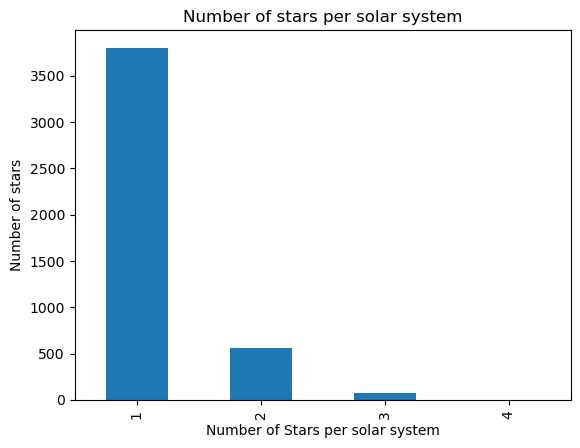

In [77]:

planet_counts = (
    sh_psc_gaia_df["sy_snum"]
    .value_counts()
    .sort_index()
)

plt.figure()
planet_counts.plot(kind="bar")
plt.xlabel("Number of Stars per solar system")
plt.ylabel("Number of stars")
plt.title("Number of stars per solar system")
plt.show()

In [79]:
# counts of stellar numbers oer solar system
star_counts = sh_psc_gaia_df["sy_snum"].value_counts().sort_index()

# get percentages
star_percent = (star_counts / len(sh_psc_gaia_df)) * 100

# combine into table so we cna view it
stellar_multiplicity_summary = (pd.DataFrame({"count": star_counts, "percentage": star_percent.round(2)}))

stellar_multiplicity_summary


,count,percentage
sy_snum,,
1,3802,85.65
2,558,12.57
3,78,1.76
4,1,0.02


total stars  = 4439
mean = 1.16
median = 
min = 0
max = 4

- Most star systems contain only 1 star, over 85%
- 12% are binary systems
- 0.02 % of solar systems have 4 stars 

This could be observational bias and the early stage fo research into exoplanets and complex multi star systems

5b2) Number of planets per star

we hav two metrics for number of planets
1) 'sy_pnum' =  4439 non-null   int64  -  derived from Stellar Hosts dataset - measured verified data from trusted source.
2) 'n_planets'  =  4189 non-null -  Int64  - derived from our data merges, only merged where we had a matching star

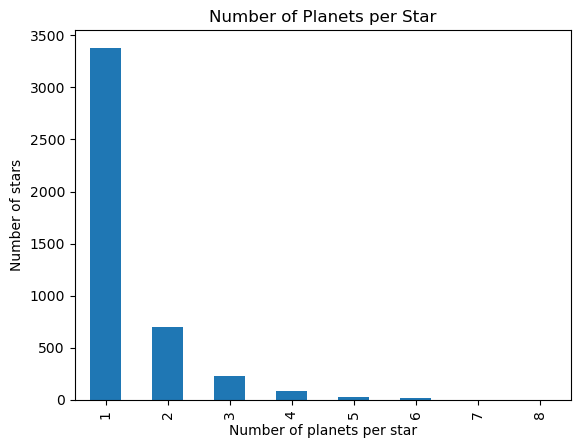

In [80]:
# plot the two together as a comparison, see how much data we lost during our data cleaning and creation approach
planet_counts = (
    sh_psc_gaia_df["sy_pnum"]
    .value_counts()
    .sort_index()
)

plt.figure()
planet_counts.plot(kind="bar")
plt.xlabel("Number of planets per star")
plt.ylabel("Number of stars")
plt.title("Number of Planets per Star")
plt.show()


total stars  = 4439
mean = 1.16
median = 
min = 0
max = 4

- Most star systems contain only 1 star, over 85%
- 12% are binary systems
- 0.02 % of solar systems have 4 stars 

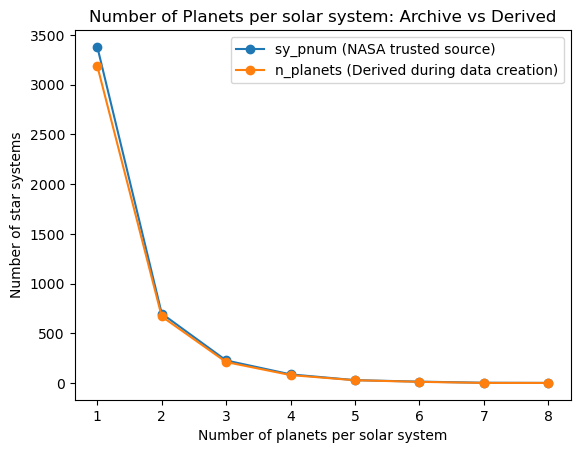

In [81]:
# crate a new df for working in
df_num_plnts_combo = sh_psc_gaia_df

# count the values for both
sy_counts = df_num_plnts_combo["sy_pnum"].value_counts().sort_index()
n_counts = df_num_plnts_combo["n_planets"].dropna().value_counts().sort_index()

# Align x-axis
all_idx = sorted(set(sy_counts.index).union(set(n_counts.index)))
sy_counts = sy_counts.reindex(all_idx, fill_value=0)
n_counts = n_counts.reindex(all_idx, fill_value=0)

plt.figure()
plt.plot(all_idx, sy_counts.values, marker="o", label="sy_pnum (NASA trusted source)")
plt.plot(all_idx, n_counts.values, marker="o", label="n_planets (Derived during data creation)")
plt.xlabel("Number of planets per solar system")
plt.ylabel("Number of star systems")
plt.title("Number of Planets per solar system: Archive vs Derived")
plt.legend()
plt.show()


- Our two value align reasonably closely and the dataset is relatively clean, no huge amounts of dat lost during the process
- sy_pnum is sllightly higher than the derived value from 1 to approx 3, then they align very closely. This may be explanable by the larger number of solar systems with 1 to 3 planets.
- > 3 planets and we have sharp decline
- The data derived across multiple data sets appears to be valid and theunderlyign process successful as shown bu the alignment with verified trusted source.

- data comparison for 'sy_pnum' and 'n_planets'
    - total = '4439' and '4189'
    - mean  values = '1.365' and '1.361'
    - median  = '1' and '1' = > > half the solar systems have > = 1 planet
    - std dev = 0.789 and 0.775 - similar spread of data values with higer values being less common
    - min = '1' and '1'
    - max = 8 and 8

Sample sizes are pretty close, both sets of data are positively skewed (right skewed)

5b3) Solar Radiation on planets  - 'insol'

Firstly lets lok at the 'psc_median_or_pl1_insol' variable

This contains data which is either a single measured/calcualed value where one radiataion data value existed or a median if more than one radiatain value existed per star, so one or median if more than 1.

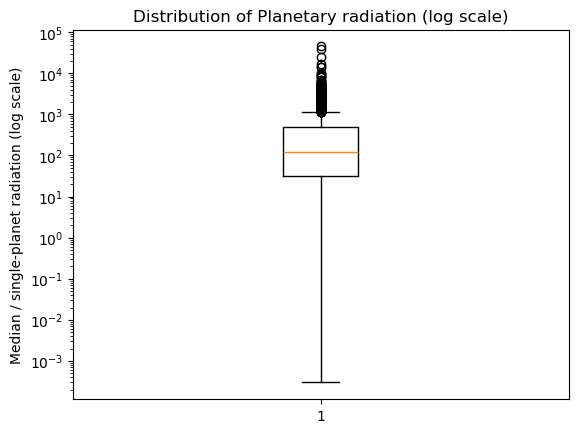

In [82]:
# flrst lets  do a boxplot to bisualise what the data looks like


# drop missing values
insol = sh_psc_gaia_df["psc_median_or_pl1_insol"].dropna()

plt.figure()
plt.boxplot(insol)
# we do a log plot as vry hard to see the data when ploted normally
# its compressed very close to the bottom, t stretches from zero to almost 50000 and is heavily clustered towards zero
plt.yscale("log")
plt.ylabel("Median / single-planet radiation (log scale)")
plt.title("Distribution of Planetary radiation (log scale)")
plt.show()



- There is a right-skew 
- There are a lot of outliers at the higher end of the scale. These correspnd to hotter stars receiving larger amounts of radiation from their star.
- mean = 489..5
- median = 120
- Mean > Median => positive right skewness
- Interquartile range is between approx 10^1 and 10^3
- Mean > Median = positive right skewness
- min = 0
- max = 44900

- Most planets received a lot of radiation and as such are probably very hot. Earth has a vlaue based arond 1 unit, an the median is 120. so radiataion around earths range is the rarer outcome, not the normal.
- Onr additional observational bias factor may be that hotter planets are easier to measure scientifically, and  to obyain data fraom. This would require further investigation however, beyond the scope of this project

5b4) Solar Mass - 'st_mass' - box plot and numerical analysis


We have two paramaters for Star mass
'st_mass' = Nasa calculated from a trusted source - solar mas units = 
'mass_flame' = GAIA provided value from flame model - solar units  = 2979 rows of data

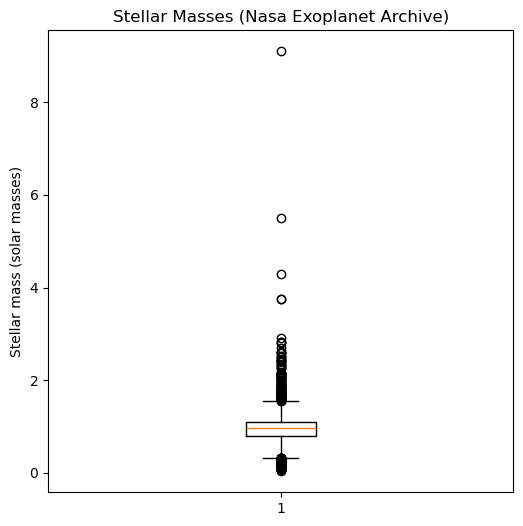

In [83]:
# firstly we'll plto the st_mass


# Ensure numeric
mass = pd.to_numeric(sh_psc_gaia_df["st_mass"], errors="coerce").dropna()

plt.figure(figsize=(6, 6))
plt.boxplot(mass, vert=True)
# plt.yscale("log")
plt.ylabel("Stellar mass (solar masses)")
plt.title("Stellar Masses (Nasa Exoplanet Archive)")
plt.show()


- Total values  = '4353' stars
- represents the mass of stars relative to the mass of our Sun, solar mass units.
- Interquartile range is between approx 0..79 and 1.09
    - Given 1 is a Soar UNit based of our Sun, that implies most star massses are in the range of our own Sun, so similar mass to our Sun.
- There are some outliers up to 9 solar masses, but these are rare
- Mean = '0.946'
- median  = '0.959' 
- mean is almost equal to Median  => is right skewed
- max value  = '9.1' => which is a hugely massive star relative to our Sun., more than 9 times the size in mass.
    - These massive stars are rare however.

We could map star class types to our sun masses, to give us tighter classifications of Star types. This could be for future analysis as it outside of the scope given the time constraints on the project 

5b5) Solar Radius - 'st_rad' and 'radius_gsppot' - box and scatter plot and numerical analysis

- 'st_rad' - Nasa trusted source data
- 'radius_gspphot' - GAIA gspoht model trusted data

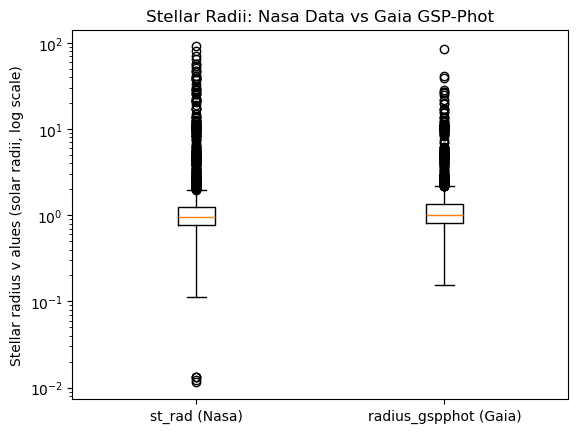

In [84]:

fig, ax = plt.subplots()

data = [
    pd.to_numeric(sh_psc_gaia_df["st_rad"], errors="coerce").dropna(),
    sh_psc_gaia_df["radius_gspphot"].dropna()
]

ax.boxplot(data, labels=["st_rad (Nasa)", "radius_gspphot (Gaia)"])
# data is squashed around zero, as such have to transform to view iog an will use log
ax.set_yscale("log")
ax.set_ylabel("Stellar radius v alues (solar radii, log scale)")
ax.set_title("Stellar Radii: Nasa Data vs Gaia GSP-Phot")

plt.show()


- Both are right skewed
- Central tendencies of both data sets are similar
- 
values for st_mass and radius_gspphot
- mean = 1.57 and 1.39
- median = 0.95 and 1.00
- mean > median  => right skewed
- std dev =  4.06 and 2,4
- min = 0.01 and 0.15
- max = 91.4 and 84.69

The Nasa data has some low values which are not present in the gaia data. There is more of a spread of data in the Nasa dataset, thsi might b related t the lower values not present in the gaia dataset. Discrepancies may be due to different measurement model or process.

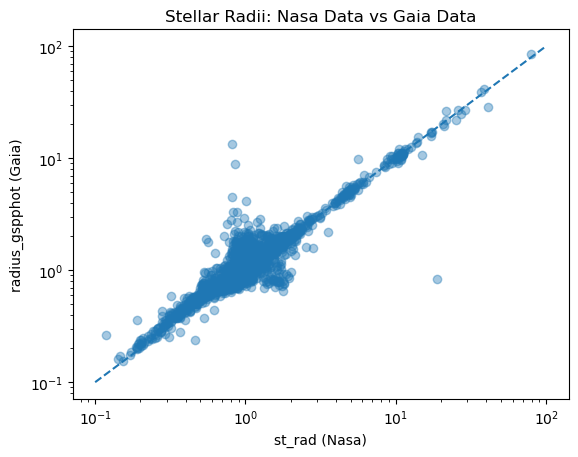

In [85]:
mask = (
    sh_psc_gaia_df["st_rad"].notna() &
    sh_psc_gaia_df["radius_gspphot"].notna()
)

plt.figure()
plt.scatter(
    sh_psc_gaia_df.loc[mask, "st_rad"],
    sh_psc_gaia_df.loc[mask, "radius_gspphot"],
    alpha=0.4
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("st_rad (Nasa)")
plt.ylabel("radius_gspphot (Gaia)")
plt.title("Stellar Radii: Nasa Data vs Gaia Data")
plt.plot([0.1, 100], [0.1, 100], linestyle="--")  # 1:1 line
plt.show()


- dashed line indicates perfect alignemnt between parameters
- x-axis is Nasa data
- y-axis is Gaia data
- using log scale for both parameters
- Strong correlation between the two parameters
- Both measurement methods/proceeses are different but the results form the plot show they are consistently alligned across a large range of stars.
- There are some outliers across both datasets, slightly more for the gaia dataset.

We can conclude that neither dataset is preferable to the other. They both appear to be as scientifically accurate, or equal, as the other. There is a strong correlation between the two datasets. While it should be expected it is still surprising to see such good alignment in scientific data determine dby two separate teams using to separate processes/methods i.e. different satellites and analysis processes. It is re-assuring.

The general exploration of the dataframe has provided us with a good insight into the data. It has provided us with confidence that the data is accurate and broad enough to be a rich data frame which we can work further with.

Given the initial large volumes of data, and the amount of filtering, cleaning, aggregation, and decisions it is re-assuring that the dataframe appears to be relatively robust, allowing us possibly have a try at answering some specific questions.

## Part 3 - Answer Questions form Data subset

Can we answer the following questions from our dataset

- Question 1: Are there many Stars in our dataset which have similar properties to our Sun, using the properties mass, radius, temperature and luminosity?

- Question 2: Are there Stars in solar systems which have Stars with similar properties to our Sun and host a similar number of planets?

- Question 3: Does the Sun provide radiation at similar levels to Earth, sufficient level to allow for life as we know  it?

3a) Sun Dataframe recap

A Reference dataframe was created earlier for our Sun with solar constant values. This will eb sued for reference and coparison with our workign dataframes



In [93]:
# have a quick look
print(f" sun shape = {sun_df.shape}")
sun_df.head(5).transpose()


 sun shape = (1, 17)


,0
hostname,Sun
st_teff,5772
st_mass,1.0
st_rad,1.0
st_lum,1.0
st_met,0.0
st_insole,1.0
st_logg,4.438
st_dens,1.408
st_rotp,25.4


In [94]:
# check of dtypes to ensure we cna use them fine in our analuysis
sun_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   hostname               1 non-null      object 
 1   st_teff                1 non-null      int64  
 2   st_mass                1 non-null      float64
 3   st_rad                 1 non-null      float64
 4   st_lum                 1 non-null      float64
 5   st_met                 1 non-null      float64
 6   st_insole              1 non-null      float64
 7   st_logg                1 non-null      float64
 8   st_dens                1 non-null      float64
 9   st_rotp                1 non-null      float64
 10  sy_pnum                1 non-null      int64  
 11  st_age                 1 non-null      float64
 12  st_spectype            1 non-null      object 
 13  earth_sun_dist         1 non-null      float64
 14  is_ref_star            1 non-null      bool   
 15  has_earth_

3b) Q1: Are there many Stars which have similar properties to our Sun using properties mass radius, temperature and luminosity?

3b1) Create a daatframe contianing thew following coluimns

- 'st_teff'
- 'st_rad'
- 'st_mass'
- 'st_lum'


Gravity data is not included e.g. 'logg_gspphot' as thsi will be implied by mass. Mass will be very strongly correlated to gravity.

In [96]:
# creae our question 1 workign dataframe
q1_df = sh_psc_gaia_df[['st_teff', 'st_rad', 'st_mass', 'st_lum']].copy()

# make sure no missing values in it
q1_df = q1_df.dropna()

Ensure dtype values are as we need 'i.e. float'

We earlier converted object dtypes to float dtypes in our main working dataframe. We will ensure that is stil the case here as we will reuires float value to perform some numeric analysis

In [97]:
# we will ensure that the columns are float numeric dytpes

stvals_to_float_2 = ['st_mass', 'st_rad', 'st_teff', 'st_lum']

for stval_2 in stvals_to_float_2:
    q1_df[stval_2] = pd.to_numeric(q1_df [stval_2], errors="coerce" )


In [98]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , q1_df.shape[0])
print ("Columns  : " , q1_df.shape[1])
print('------')
print ("\nFeatures : \n" , q1_df.columns.tolist())
print('------')
print ("\nMissing values :  ", q1_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", q1_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(q1_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", q1_df.nunique())
print('------')
print('\n null values = ', q1_df.isnull().values.any())
print('------')
q1_df_missing = (q1_df=='?').sum()
print('\"  ?   \" values present =  \n', q1_df_missing)
print('------')
q1_df_unknown = (q1_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',q1_df_unknown)
print('------')
q1_df_na = q1_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', q1_df_na)
print('------')
q1_df_none = q1_df.isin(['None', 'none']).sum()
print('    none    values present = \n', q1_df_none)

Rows     :  4232
Columns  :  4
------

Features : 
 ['st_teff', 'st_rad', 'st_mass', 'st_lum']
------

Missing values :   0
------

Missing values per column:   st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------

num of dups in df   =   0
------

Unique values :  
 st_teff    2964
st_rad     3033
st_mass    1930
st_lum     4115
dtype: int64
------

 null values =  False
------
"  ?   " values present =  
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------
"   unknown   " values present =  
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------
    NA     values present = 
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------
    none    values present = 
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64


In [99]:
# have a lok at info() data
q1_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4232 entries, 0 to 4438
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   st_teff  4232 non-null   float64
 1   st_rad   4232 non-null   float64
 2   st_mass  4232 non-null   float64
 3   st_lum   4232 non-null   float64
dtypes: float64(4)
memory usage: 165.3 KB


In [100]:
print(f" ... {q1_df.describe()}")

 ...             st_teff       st_rad      st_mass       st_lum
count   4232.000000  4232.000000  4232.000000  4232.000000
mean    5334.472409     1.587008     0.945786    -0.133659
std     1185.481871     4.109301     0.325985     0.802779
min     2562.500000     0.117000     0.051000    -3.258060
25%     4862.155000     0.770000     0.789750    -0.495915
50%     5546.075000     0.958237     0.960000    -0.058940
75%     5918.442500     1.254125     1.094625     0.336317
max    40000.000000    91.403900     4.300000     3.260760


3b2) - specify data ranges to remove outliers

Data contains some outliers which are out of scope for reference with our Sun. They will be very far out of range in coparison wth our Sun references.

We will apply a range of values to narrow our focus in our data, 

Specify range value which are approx 50% + or - our Sun data

In [175]:
sun_teff = sun_df["st_teff"].iloc[0]
sun_mass = sun_df["st_mass"].iloc[0]
sun_rad  = sun_df["st_rad"].iloc[0]
sun_lum  = sun_df["st_lum"].iloc[0]
print(sun_teff)
print(sun_mass)
print(sun_rad)
print(sun_lum)

# to be within a raneg or + or - 10 %, 25% or 50% of the sun values 
# will find out if there is an exact match also.. a twin
pc_10_value = .1  
pc_25_value = .25
pc_50_value = .5
twin_value = 0.01  #( or very close to identical match i.e. 0.01 )

print(f" ==============50 percent + or - Sun values === Below =================")

# between reurns a boolean mask must apply the bool mask to the dataframe then
q1_ranges_incl_df = q1_df[
    (q1_df["st_teff"].between(sun_teff * (1-pc_50_value), sun_teff * (1+pc_50_value))) &
    (q1_df["st_mass"].between(sun_mass * (1-pc_50_value), sun_mass * (1+pc_50_value))) &
    (q1_df["st_rad"].between(sun_rad * (1-pc_50_value), sun_rad * (1+pc_50_value))) &
    (q1_df["st_lum"].between(-np.log10(1 + pc_50_value), np.log10(1 + pc_50_value)))
].copy()

print(q1_ranges_incl_df)
print(q1_ranges_incl_df.shape)
print(q1_ranges_incl_df.head())

# =============== we'll get numbers for 10% and 25% =====
print(f" ==============25 percent + or - Sun values === Below =================")
q1_25pc_df = q1_df[
    (q1_df["st_teff"].between(sun_teff * (1-pc_25_value), sun_teff * (1+pc_25_value))) &
    (q1_df["st_mass"].between(sun_mass * (1-pc_25_value), sun_mass * (1+pc_25_value))) &
    (q1_df["st_rad"].between(sun_rad * (1-pc_25_value), sun_rad * (1+pc_25_value))) &
    (q1_df["st_lum"].between(-np.log10(1 + pc_25_value), np.log10(1 + pc_25_value)))
].copy()

print(q1_25pc_df)
print(q1_25pc_df.shape)
print(q1_25pc_df.head())
# =============== we'll get numbers for 10% and 25% =====
print(f" ==============10 percent + or - Sun values === Below  =================")
q1_10pc_df = q1_df[
    (q1_df["st_teff"].between(sun_teff * (1-pc_10_value), sun_teff * (1+pc_10_value))) &
    (q1_df["st_mass"].between(sun_mass * (1-pc_10_value), sun_mass * (1+pc_10_value))) &
    (q1_df["st_rad"].between(sun_rad * (1-pc_10_value), sun_rad * (1+pc_10_value))) &
    (q1_df["st_lum"].between(-np.log10(1 + pc_10_value), np.log10(1 + pc_10_value)))
].copy()

print(q1_10pc_df)
print(q1_10pc_df.shape)
print(q1_10pc_df.head())


print(f" ============== Exact match of Sun values a Twin === Below  =================")

q1_exact_match_df = q1_df[
    (q1_df["st_teff"].between(sun_teff * (1-twin_value), sun_teff * (1+twin_value))) &
    (q1_df["st_mass"].between(sun_mass * (1-twin_value), sun_mass * (1+twin_value))) &
    (q1_df["st_rad"].between(sun_rad * (1-twin_value), sun_rad * (1+twin_value))) &
    (q1_df["st_lum"].between(-np.log10(1 + twin_value), np.log10(1 + twin_value)))
].copy()


print(q1_exact_match_df)
print(q1_exact_match_df.shape)
print(q1_exact_match_df.head())




5772
1.0
1.0
1.0
 ==============50 percent + or - Sun values === Below =================
       st_teff    st_rad  st_mass   st_lum
4     5423.665  1.202170    0.954  0.05436
7     5792.000  0.944233    0.965 -0.03995
11    5835.000  0.990000    1.060 -0.03543
21    5500.000  0.920000    0.920 -0.17064
29    5380.000  0.959522    0.910 -0.15859
...        ...       ...      ...      ...
4422  5930.000  1.066000    1.030  0.09007
4423  5703.000  0.921000    0.998 -0.12830
4425  5913.000  1.008000    1.014  0.07901
4427  5955.500  1.001000    1.079  0.16457
4431  5952.000  1.041500    1.057  0.11547

[954 rows x 4 columns]
(954, 4)
     st_teff    st_rad  st_mass   st_lum
4   5423.665  1.202170    0.954  0.05436
7   5792.000  0.944233    0.965 -0.03995
11  5835.000  0.990000    1.060 -0.03543
21  5500.000  0.920000    0.920 -0.17064
29  5380.000  0.959522    0.910 -0.15859
 ==============25 percent + or - Sun values === Below =================
       st_teff    st_rad  st_mass   st_lum
4

- Total number of stars in our q1_df = 4232
    - Number of stars within **10%** of Suns values for temp, radius, mass and luminosity in our dataset = **169**
    - Number of stars within **25%** of Suns values for temp, radius, mass and luminosity in our dataset = **523**
    - Number of stars within **50%** of of Suns values for temp, radius, mass and luminosity in our dataset = **954**

- There is no star with an exact match to 0.01 percent of the Sun for mass, radius, temp and luminosity. 
    - The Sun does not have a twin, at least not in our dataset.


Verify the new 50% Sun similar Star data to ensure its integrity

In [157]:
# quick look at data to see if its clean, no duplicates, null values unusual characters etc
# convert it to d first so can easily run some checks over it
#stellar_host_df=pd.DataFrame(processed_per_file_data)
# view various dataframe details
# checking for null values and specific unknown values
print ("Rows     : " , q1_ranges_incl_df.shape[0])
print ("Columns  : " , q1_ranges_incl_df.shape[1])
print('------')
print ("\nFeatures : \n" , q1_ranges_incl_df.columns.tolist())
print('------')
print ("\nMissing values :  ", q1_ranges_incl_df.isnull().sum().values.sum())
print('------')
print ("\nMissing values per column:  ", q1_ranges_incl_df.isnull().sum())
print('------')
print('\nnum of dups in df   =   {}'.format(q1_ranges_incl_df.duplicated().sum()))
print('------')
print ("\nUnique values :  \n", q1_ranges_incl_df.nunique())
print('------')
print('\n null values = ', q1_ranges_incl_df.isnull().values.any())
print('------')
q1_ranges_incl_df_missing = (q1_ranges_incl_df=='?').sum()
print('\"  ?   \" values present =  \n', q1_ranges_incl_df_missing)
print('------')
q1_ranges_incl_df_unknown = (q1_df=='unknown').sum()
print('\"   unknown   \" values present =  \n',q1_ranges_incl_df_unknown)
print('------')
q1_ranges_incl_df_na = q1_ranges_incl_df.isin(['N/A', 'N\\A', 'NA', 'n/a', 'n\\A', 'na', 'N_A']).sum()
print('    NA     values present = \n', q1_ranges_incl_df_na)
print('------')
q1_ranges_incl_df_none = q1_ranges_incl_df.isin(['None', 'none']).sum()
print('    none    values present = \n', q1_ranges_incl_df_none)

Rows     :  954
Columns  :  4
------

Features : 
 ['st_teff', 'st_rad', 'st_mass', 'st_lum']
------

Missing values :   0
------

Missing values per column:   st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------

num of dups in df   =   0
------

Unique values :  
 st_teff    685
st_rad     709
st_mass    471
st_lum     928
dtype: int64
------

 null values =  False
------
"  ?   " values present =  
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------
"   unknown   " values present =  
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------
    NA     values present = 
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64
------
    none    values present = 
 st_teff    0
st_rad     0
st_mass    0
st_lum     0
dtype: int64


In [158]:
q1_ranges_incl_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 954 entries, 4 to 4431
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   st_teff  954 non-null    float64
 1   st_rad   954 non-null    float64
 2   st_mass  954 non-null    float64
 3   st_lum   954 non-null    float64
dtypes: float64(4)
memory usage: 37.3 KB


In [159]:
print(q1_ranges_incl_df.describe())

           st_teff      st_rad     st_mass      st_lum
count   954.000000  954.000000  954.000000  954.000000
mean   5738.318753    1.009492    0.994495   -0.005705
std     219.825786    0.108948    0.075831    0.100653
min    4479.500000    0.710000    0.731000   -0.175990
25%    5598.125000    0.935000    0.947200   -0.093815
50%    5731.000000    0.999000    1.000000   -0.003360
75%    5871.000000    1.075784    1.046000    0.075368
max    6497.500000    1.485000    1.322750    0.176090


3b3) Validation of data after applying ranges to data

- we have good numbers of unique values per column in our 954 stars within 50% range of our Sun's temp, mass, radius and luminosity data.
- Our dtypes for our 4 paramters are all floats as expected
- We have no missing values per column
- numbers of unique values per column
    - 'st_teff' =  685
    - 'st_rad' = 709
    - 'st_mass' = 471
    - 'st_lum' = 928

- Standard deviation values around .1 for radius, mass and luminosity which means there is not a lot of spread in the data
- Our mean and median values are also very close to our Sun reference value of 1. which means our data is reasonably well centred around this Sun standard value
- IQR values for measure of sprread are approx .1 across mass, rad and luminosity
- Mean temp value of 5683 and median of 5738 means there are not large outliers and the data is close to our Sun temp of approx 5772

Filtering for + or - roughly 50% of the Sun values gives us 954 rows, or 954 individual stars falling within this range.

This is still a significant sample which we can use

3b4) Plot of Mass Radius relationship

we will plot mass and radius and see if there is a correlation between them

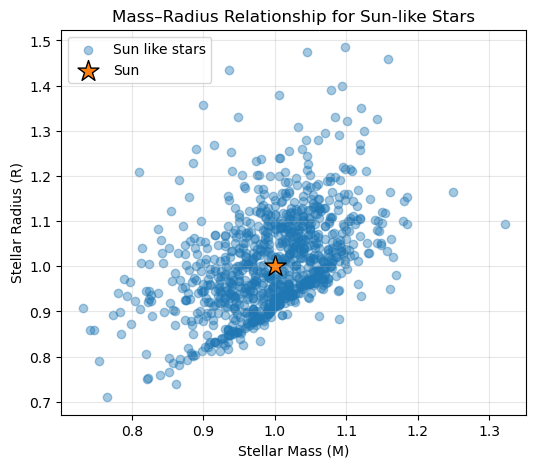

In [ ]:

plt.figure(figsize=(6,5))

plt.scatter(q1_ranges_incl_df["st_mass"], q1_ranges_incl_df["st_rad"], alpha=0.4, label="Sun like stars")

# sun data marker definition
plt.scatter(1.0, 1.0, marker="*", s=250, edgecolor="black", label="Sun")

plt.xlabel("Stellar Mass (M)")
plt.ylabel("Stellar Radius (R)")
plt.title("Mass–Radius Relationship for Sun like stars")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- There is a positive correlation between star mass and radius
    - The larger the star the larger the radius
- Sun sits int he centre , which is as expected as we have a range of + or - .5 based off the Sun's constant values. 
- The sun is not an outlier
- No extreme outliers, some with large mass and shorter radius, buyt the general trend correlation trend is apparent.


3b5) Plot of Temperature Radius relationship

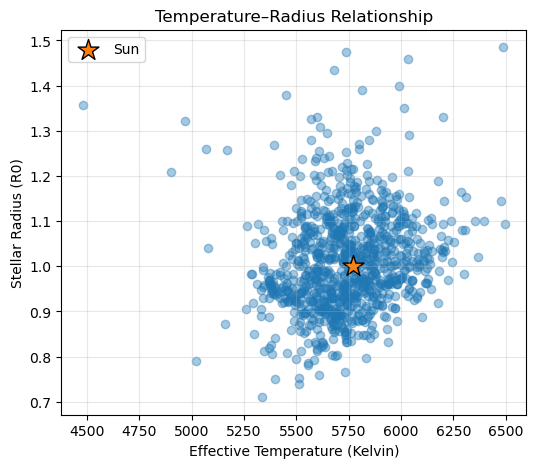

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(q1_ranges_incl_df["st_teff"], q1_ranges_incl_df["st_rad"], alpha=0.4)

# sun data marker definition
plt.scatter(5772, 1.0, marker="*", s=250, edgecolor="black", label="Sun like stars")

plt.xlabel("Effective Temperature (Kelvin)")
plt.ylabel("Stellar Radius (R0)")
plt.title("Temperature–Radius Relationship for Sun like stars")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


- Again Sun lies in the centre of the data
- no tails or outliers
- There is a weak correlation of temperature and radius, hotter stars havign slightly loarger radii, but it is not necessarily a strong correlation.

3b6) Plot of Temperature Luminosity relationship

This is known as a [Hertzsprung–Russell](htps://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram) diagram and is a well known star plot in astrophysics.

Our version will just be for a subset of theone in the link, just plotting star like stars 

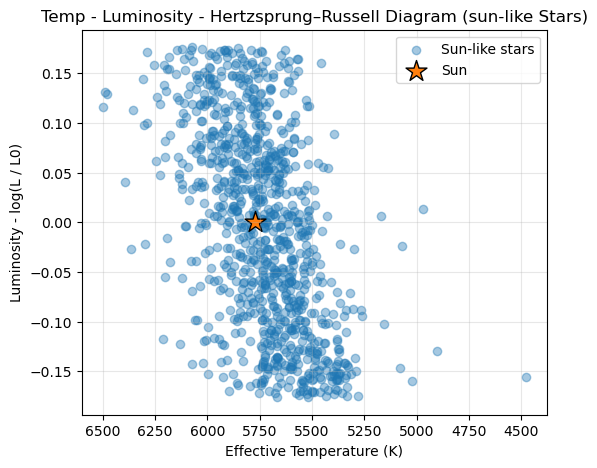

In [ ]:
plt.figure(figsize=(6,5))

plt.scatter(q1_ranges_incl_df["st_teff"],q1_ranges_incl_df["st_lum"], alpha=0.4, label="Sun like stars")

# sun data marker definition
plt.scatter(5772, 0.0, marker="*", s=250,edgecolor="black", label="Sun")

# invert x axis
plt.gca().invert_xaxis() 
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Luminosity - log(L / L0)")
plt.title("Temp - Luminosity (Hertzsprung–Russell Diagram) for Sun like stars)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Again Sun sits in centre of our data as expected, implying the Sun is not an outlier or unusual
- Hotter is to the left, so our x axis is inverted
- There is a medium strength correlation between luminosity and Temperature i.e. the hotter the star the higher the Luminosity.


3b7) Anser to question 1)

- Q1: Are there many Stars which have similar properties to our Sun using properties mass radius, temperature and luminosity?

- Answer:
    - we cna see form the data and analysis that the sun is not unique
    - in our data set there are 954 stars with properties within 50% of the suns values
    - we saw that even within 10% of the suns properties there are 169 stars with similar properties
    - So, yes, the sun is not unique and there are stars with the similar properties to our sun
        - In short the sun does have cousins, if not brothers 
        - Unfortunately it does not have a twin...at least in our dataset


3c1)  Question 2: Are there Stars in other solar systems, which have Stars with similar properties to our Sun and host a similar number of planets ?

we'll build on the last data set of having similar properties to our Sun i.e. temp, mass, radius and luminoscity and add the details around number of planets per star, to enhanced the dataset.

The ultimate question is where could there possibly be life outside of Earth. This will build to that.

We loked at number of planets earlier in Part 2, however that was in a general context of all stars in general. We do so here in a different context i.e. how many solar systems are there with 'sun like stars' who have a similar number of planets. i.e. does our solar system have a twin or maybe a cousin..

- We have two columns with planet number data
    - 'sy_pnum'
    - 'n_planets' 
    

In [ ]:
# Append to the existing dataframe with planet number data

---review---
Scatter plots of stellar mass, radius, effective temperature, and luminosity reveal well-defined relationships within the Sun-like subset. 

In all cases, the Sun lies within the central area of the distributions rather than at their extremes. 

This demonstrates that stars with properties similar to the Sun are common in the dataset and that the Sun itself is a typical main-sequence star in terms of its fundamental stellar characteristics.

The breadth may be too wide. for future analysis we could narrow the range to wihtin 80% or 90% of the suns properties.

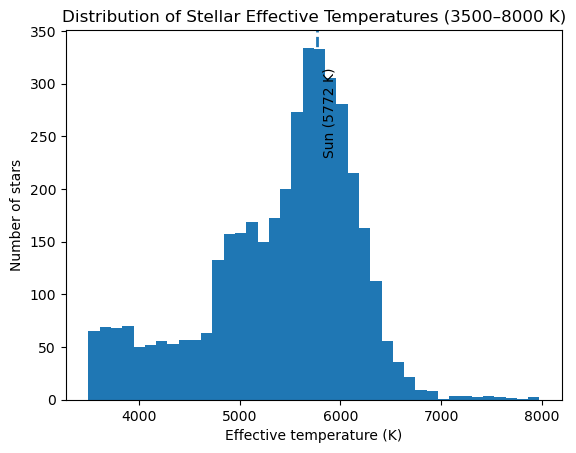

In [104]:
# crate temp df for our plot so outliers don't affect our view of relevant data
teff_plot_df = q1_df[q1_df["st_teff"].between(3500, 8000)]

sun_teff = sun_df["st_teff"].iloc[0]

plt.hist(teff_plot_df["st_teff"], bins=40)

# Sun marker
plt.axvline(
    sun_teff,
    linestyle="--",
    linewidth=2
)

# Annotate
plt.text(
    sun_teff + 50,
    plt.ylim()[1] * 0.9,
    "Sun (5772 K)",
    rotation=90,
    va="top"
)

plt.xlabel("Effective temperature (K)")
plt.ylabel("Number of stars")
plt.title("Distribution of Stellar Effective Temperatures (3500–8000 K)")
plt.show()



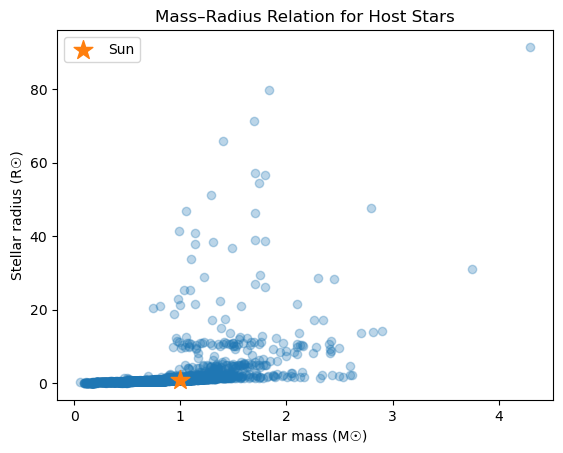

In [105]:
plt.scatter(q1_df["st_mass"], q1_df["st_rad"], alpha=0.3)
plt.scatter(
    sun_df["st_mass"],
    sun_df["st_rad"],
    marker="*",
    s=200,
    label="Sun"
)
plt.xlabel("Stellar mass (M☉)")
plt.ylabel("Stellar radius (R☉)")
plt.title("Mass–Radius Relation for Host Stars")
plt.legend()
plt.show()



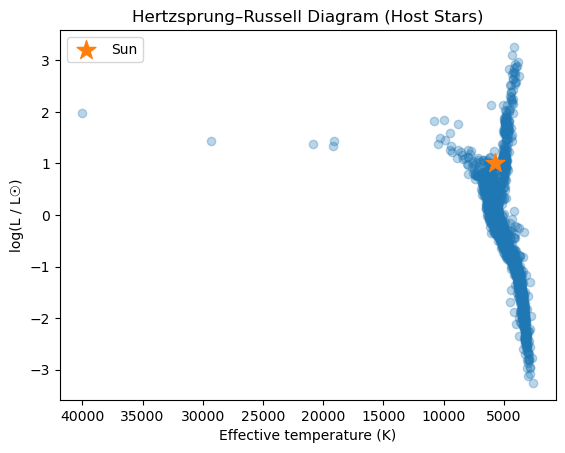

In [106]:
plt.scatter(q1_df["st_teff"], q1_df["st_lum"], alpha=0.3)
plt.scatter(
    sun_df["st_teff"],
    sun_df["st_lum"],
    marker="*",
    s=200,
    label="Sun"
)
plt.gca().invert_xaxis()
plt.xlabel("Effective temperature (K)")
plt.ylabel("log(L / L☉)")
plt.title("Hertzsprung–Russell Diagram (Host Stars)")
plt.legend()
plt.show()


CReate a column parameter table from our dictionaries and our dataframe

In [345]:
# create dataframe from each col dictinary we crdated arlier
df_cols = set(sh_psc_gaia_df.columns)


In [346]:
# crate function to lok up asw il sue again
def dict_to_df(web_dict, source_name):
    return (pd.DataFrame(web_dict)[["db_col_name", "label", "description"]]
        .rename(columns={"db_col_name": "column"})
        .assign(source=source_name)
    )


In [347]:
sh_defs = dict_to_df(sh_web_col_defs_dict, "NASA Exoplanet Archive (Stellar Hosts)")
sh_match = sh_defs[sh_defs["column"].isin(df_cols)]

remaining = df_cols - set(sh_match["column"])


In [348]:
psc_defs = dict_to_df(psc_web_col_defs_dict, "NASA Exoplanet Archive (PSC)")
psc_match = psc_defs[psc_defs["column"].isin(remaining)]

remaining = remaining - set(psc_match["column"])


In [349]:
gaia_defs = dict_to_df(gaia_web_col_defs_dict, "Gaia DR3")
gaia_match = gaia_defs[gaia_defs["column"].isin(remaining)]

remaining = remaining - set(gaia_match["column"])


In [350]:
column_dictionary = (
    pd.concat([sh_match, psc_match, gaia_match], ignore_index=True)
    .sort_values("column")
    .reset_index(drop=True)
)

column_dictionary

,column,label,description,source
0,ag_gspphot,float,Extinction in G band from GSP-Phot Aeneas best...,Gaia DR3
1,cb_flag,circumbinary_flag,Flag indicating whether the planet orbits a bi...,NASA Exoplanet Archive (Stellar Hosts)
2,dec,dec_decimal,Declination of the planetary \n syst...,NASA Exoplanet Archive (Stellar Hosts)
3,distance_gspphot,float,Distance from GSP-Phot Aeneas best library usi...,Gaia DR3
4,gaia_dr2_id,gaia_dr2_id,Name of the star as given by the Gaia DR2 Catalog,NASA Exoplanet Archive (Stellar Hosts)
5,gaia_dr3_id,gaia_dr3_id,Name of the star as given by the Gaia DR3 Catalog,NASA Exoplanet Archive (Stellar Hosts)
6,hd_name,hd_id,Name of the star as given by the Henry Draper ...,NASA Exoplanet Archive (Stellar Hosts)
7,hip_name,hip_id,Name of the star as given by the Hipparcos Cat...,NASA Exoplanet Archive (Stellar Hosts)
8,hostname,host_name,Stellar name most commonly used in the literature,NASA Exoplanet Archive (Stellar Hosts)
9,logg_gspphot,float,Surface gravity from GSP-Phot Aeneas best libr...,Gaia DR3


In [351]:
print("Columns not found in web dictionaries:")
for col in sorted(remaining):
    print(" -", col)

cols_no_description = [
    "age_flame",
    "evolstage_flame",
    "gaia_dr3_num",
    "lum_flame",
    "mass_flame",
    "mg_gspphot",
    "n_missing",
    "n_planets",
    "psc_in_earth_range_insol",
    "psc_median_or_pl1_insol",
    "psc_n_planets_with_insol",
    "radius_gspphot",
]



Columns not found in web dictionaries:
 - age_flame
 - evolstage_flame
 - gaia_dr3_num
 - lum_flame
 - mass_flame
 - mg_gspphot
 - n_missing
 - n_planets
 - psc_in_earth_range_insol
 - psc_median_or_pl1_insol
 - psc_n_planets_with_insol
 - radius_gspphot


In [352]:
# manually define missing columns into dict o cna merge them all tgether
manual_col_defs = pd.DataFrame([
    {
        "column": "age_flame",
        "label": "stellar_age_flame_gyr",
        "description": "Stellar age (Gyr) from flame model",
        "source": "manual"
    },
    {
        "column": "evolstage_flame",
        "label": "stellar_evolution_stage_flame",
        "description": "Stellar evolutionary stage from flame model",
        "source": "manual"
    },
    {
        "column": "gaia_dr3_num",
        "label": "gaia_dr3_numeric_id",
        "description": "Numeric version of gaia_dr3_id",
        "source": "manual"
    },
    {
        "column": "lum_flame",
        "label": "stellar_luminosity_flame",
        "description": "Stellar luminosity from flame model",
        "source": "manual"
    },
    {
        "column": "mass_flame",
        "label": "stellar_mass_flame",
        "description": "Stellar mass est from flame model",
        "source": "manual"
    },
    {
        "column": "mg_gspphot",
        "label": "absolute_g_band_magnitude",
        "description": "G-band magnitude brighness",
        "source": "manual"
    },
    {
        "column": "n_missing",
        "label": "num_missing_values",
        "description": 'number of missing values in a row',
        "source": "manual"
    },
    {
        "column": "n_planets",
        "label": "total_confirmed_planets",
        "description": "number of planets associated with a star",
        "source": "manual"
    },
    {
        "column": "psc_in_earth_range_insol",
        "label": "earth_like_insolation_flag",
        "description": "Boolean if planet receievs radiatino from star simioar to earth from Sun",
        "source": "manual"
    },
    {
        "column": "psc_median_or_pl1_insol",
        "label": "median_or_single_planet_insolation",
        "description": "Median radiation received value where planet is > 1 for star",
        "source": "manual"
    },
    {
        "column": "radius_gspphot",
        "label": "stellar_radius_gspphot",
        "description": "Stellar radius est from gspphot model",
        "source": "manual"
    },
        {
        "column": "psc_n_planets_with_insol",
        "label": "num_planets_with_insolation",
        "description": "Number of confirmed planets receivig star radition",
        "source": "manual"
    }
])

In [353]:
# merge the two colmn dataframes
column_dictionary = (pd.concat([column_dictionary, manual_col_defs ], ignore_index=True).sort_values("column").reset_index(drop=True))

column_dictionary

,column,label,description,source
0,ag_gspphot,float,Extinction in G band from GSP-Phot Aeneas best...,Gaia DR3
1,age_flame,stellar_age_flame_gyr,Stellar age (Gyr) from flame model,manual
2,cb_flag,circumbinary_flag,Flag indicating whether the planet orbits a bi...,NASA Exoplanet Archive (Stellar Hosts)
3,dec,dec_decimal,Declination of the planetary \n syst...,NASA Exoplanet Archive (Stellar Hosts)
4,distance_gspphot,float,Distance from GSP-Phot Aeneas best library usi...,Gaia DR3
5,evolstage_flame,stellar_evolution_stage_flame,Stellar evolutionary stage from flame model,manual
6,gaia_dr2_id,gaia_dr2_id,Name of the star as given by the Gaia DR2 Catalog,NASA Exoplanet Archive (Stellar Hosts)
7,gaia_dr3_id,gaia_dr3_id,Name of the star as given by the Gaia DR3 Catalog,NASA Exoplanet Archive (Stellar Hosts)
8,gaia_dr3_num,gaia_dr3_numeric_id,Numeric version of gaia_dr3_id,manual
9,hd_name,hd_id,Name of the star as given by the Henry Draper ...,NASA Exoplanet Archive (Stellar Hosts)


In [354]:
# check aghainst the dataframe 
missing_defs = set(sh_psc_gaia_df.columns) - set(column_dictionary["column"])

print("Undocumented columns:")
for col in sorted(missing_defs):
    print(" -", col)
    
assert set(sh_psc_gaia_df.columns) == set(column_dictionary["column"])



Undocumented columns:


In [355]:
df_cols = set(sh_psc_gaia_df.columns)
dict_cols = set(column_dictionary["column"])

missing_in_dict = df_cols - dict_cols
extra_in_dict = dict_cols - df_cols

print("Columns in dataframe but NOT in dictionary:")
print(sorted(missing_in_dict))

print("\nColumns in dictionary but NOT in dataframe:")
print(sorted(extra_in_dict))


Columns in dataframe but NOT in dictionary:
[]

Columns in dictionary but NOT in dataframe:
[]


#### Appendix) LAMOST (Latge Sky Area Multi-Object Fiber Spectroscopic Telescope)

detaisl available from her > https://www.lamost.org/public/?locale=en 

DR13 s tye latest set of data but you need lgigin IDs and approval to downlaod ans use, hence we will sue an older set pf daya DR11.

https://www.lamost.org/dr11/v2.0/catalogue

there are options to downlaod via FTP or european mirrors btu accoutns are required for login, am still aiting for approval, column names have ben altered in some mirrors also. The other optji is tok manually download. I have chosent o manually down catalogue and then filter locally. 

I have queried to see colimn mames >> https://www.lamost.org/dr11/v2.0/table/stellar and ti has a gaia_source_id column whicj we cna merge on.

We wil download the LAMOST MRS Parameter Catalogue. This is approx 1GB in size and download took approximately 20 mins. we re-crate a smaller filtered csv off that full csv catalogue download. 

I Decided to manually download the dataset > dr11_v2.0_MRS_stellar.fits > dr11_v2.0_MRS_stellar.fits.gz
- It is approx 1 GB in size when extracted - too big to include in assignmnt hand off. So in case ipynb file needs to be run, I will create smaller fit file for inclusiong off this 2gb fit file and will include thatyin the hand off.
= extract the tar.gz file
- build dataframe from extracted fit file
- it has a shape of (7898024, 45)

we will use FIT fie format to try help avoin d any corruption when covertign from csv



In [ ]:
# including code here but commenting out as its not intended ot be run again. csv has already been created off manually downlaoded 
# lamost fits  file
# master dataframe has a shape of >> (7898024, 45)

# Load FITS file
lamost_fits_file = f"{path}dr11_v2.0_MRS_stellar.fits"   
lamost_fits_tbl = Table.read(lamost_fits_file)

# Convert entire table to a pandas DataFrame
lamost_full_stellar_cat_fits_df = lamost_fits_tbl.to_pandas()

print(lammost_full_stellar_cat_fits_df.shape)
lamost_full_stellar_cat_fits_df.head()


(7898024, 45)


,mobsid,obsid,uid,gp_id,designation,obsdate,lmjd,mjd,planid,spid,...,ca_fe,ti_fe,cr_fe,ni_fe,cu_fe,alpha_m_lasp,alpha_m_lasp_err,moon_angle,lunardate,moon_flg
0,b'589102005B',589102005,b'G13674228956942',2007175828177988096,b'J225320.50+574949.7',b'2017-09-28',58025,58024,b'apogee_field0101',2,...,-0.09265,-9999.00000,-9999.00000,0.02812,-9999.00000,0.030230,0.016372,94.5,9,b'0'
1,b'589102011B',589102011,b'G13674230881236',2007179710828415232,b'J225236.56+575228.9',b'2017-09-28',58025,58024,b'apogee_field0101',2,...,0.04382,-0.01623,-0.02655,0.01371,0.02801,0.013985,0.038074,94.5,9,b'0'
2,b'589102021B',589102021,b'G13674222921556',2007196276531913216,b'J225237.17+580219.0',b'2017-09-28',58025,58024,b'apogee_field0101',2,...,-0.01571,-9999.00000,-9999.00000,-0.01356,-9999.00000,-9999.000000,-9999.000000,94.5,9,b'0'
3,b'589102027B',589102027,b'G13673784720856',2007438409604543104,b'J224808.02+582034.5',b'2017-09-28',58025,58024,b'apogee_field0101',2,...,0.00009,-9999.00000,-9999.00000,-0.04321,-9999.00000,-0.071275,0.041089,94.5,9,b'0'
4,b'589102029B',589102029,b'G13674121929935',2007452424071586560,b'J224926.62+582734.1',b'2017-09-28',58025,58024,b'apogee_field0101',2,...,0.13706,-0.11110,0.02287,0.03556,0.20856,-9999.000000,-9999.000000,94.5,9,b'0'


In [146]:
# gives a shape of (7898024, 45)
lamost_col_dtype_info_df = (
    lamost_full_stellar_cat_fits_df
    .dtypes
    .reset_index()
    .rename(columns={"index": "column", 0: "dtype"})
)



lamost_col_dtype_info_dict = dict(zip(lamost_col_dtype_info_df["column"], lamost_col_dtype_info_df["dtype"]))


lamost_col_dtype_info_dict

{'mobsid': dtype('O'),
 'obsid': dtype('int32'),
 'uid': dtype('O'),
 'gp_id': dtype('int64'),
 'designation': dtype('O'),
 'obsdate': dtype('O'),
 'lmjd': dtype('int32'),
 'mjd': dtype('int32'),
 'planid': dtype('O'),
 'spid': dtype('int16'),
 'fiberid': dtype('int16'),
 'lmjm': dtype('int32'),
 'band': dtype('O'),
 'ra_obs': dtype('float64'),
 'dec_obs': dtype('float64'),
 'snr': dtype('float32'),
 'gaia_source_id': dtype('O'),
 'gaia_g_mean_mag': dtype('float32'),
 'gaia_bp_mean_mag': dtype('float32'),
 'gaia_rp_mean_mag': dtype('float32'),
 'fibertype': dtype('O'),
 'offsets': dtype('int16'),
 'offsets_v': dtype('float32'),
 'ra': dtype('float64'),
 'dec': dtype('float64'),
 'teff_lasp': dtype('float32'),
 'teff_lasp_err': dtype('float32'),
 'logg_lasp': dtype('float32'),
 'logg_lasp_err': dtype('float32'),
 'feh_lasp': dtype('float32'),
 'feh_lasp_err': dtype('float32'),
 'vsini_lasp': dtype('float32'),
 'vsini_lasp_err': dtype('float32'),
 'rv_b0': dtype('float32'),
 'rv_b0_err':

In [148]:
# Filter for GAIS DR3 IDs  - we onyl keep those entries that we can match across datasets
# this will be our workign dataframe - which we will clan properly then.
# was using a loop but was takign too long....

# m,ake sure both dtypes in the id list w created earlier and the downlaoded lamost catalogue are both str dtyeps
lamost_full_stellar_cat_fits_df["gaia_source_id"] = (lamost_full_stellar_cat_fits_df["gaia_source_id"].astype(str).str.strip().replace(['None', 'nan', 'NaN', '', ',' '.'], pd.NA))

# 
sh_clean_gaiaid_num_list = [str(x) for x in sh_clean_gaiaid_num_list]



In [ ]:
lamost_matched_df = lamost_full_stellar_cat_fits_df[lamost_full_stellar_cat_fits_df["gaia_source_id"].isin(sh_clean_gaiaid_num_list)]

print("Matches:", lamost_matched_df.shape)

# DR10 = Matches: (838, 76)
# DR11 = Matches: (968, 76)

Matches: (968, 76)


968 star matches across the GAIA DR3 and LAMOST DR11 datasets seems like a low number. We validate the results below again, to double check our data.

- GAIA DR3 has 45K+ unique stars
- LAMOST DR11 has 2.5 million + unique stars
- It may be explainable due to different parts of the sky being observed i.e. China vs Europe and the overlap between those.
- Another explanation may eb the LAMOST dataset ot being the latest, perhaps DR13 dataset being the latest and a bigger dataset, would have more matches
-  It would require further investigation to determine, which is beyond the scope of the time we have available for this assignemnt at the moment.

In [150]:
print(f" Number of gaia dr3 ids we have in our list to check against =  {len(sh_clean_gaiaid_num_list)}")

print(f" Number of unique non empty lamost ids that we are matchig againsty = {lamost_full_stellar_cat_fits_df["gaia_source_id"].notna().sum()}")

print(f" Matchign Stars across the GAIA DR£ and LAMOST DR11 datasets =  {len(set(sh_clean_gaiaid_num_list) & set(lamost_full_stellar_cat_fits_df["gaia_source_id"].dropna()))}")


 Number of gaia dr3 ids we have in our list to check against =  45132
 Number of unique non empty lamost ids that we are matchig againsty = 2594070
 Matchign Stars across the GAIA DR£ and LAMOST DR11 datasets =  294


we'll now crate a new lamost dr11 dataframe that contains only stars which have a match gaia id 

In [ ]:
# filter the dr11 dataframe for gaia ids matches
lamost_gaiaid_matched_dr11_df = lamost_full_stellar_cat_fits_df[lamost_full_stellar_cat_fits_df["gaia_source_id"].isin(sh_clean_gaiaid_num_list)].copy()

print(f" new lamost gaisid matched dr11 dataframe shape =  {lamost_gaiaid_matched_dr11_df.shape}")

 new lamost gaisid matched dr11 dataframe shape =  (968, 76)


We'll now modufy this new lamost gaia matched dataframe to include just the columns we want. We will check against our earlier created dictionary of all the columns to ensure we ahve the corrcet column labels.

In [161]:
cols_to_keep  = ["gaia_source_id", "obsid", "uid", "designation", "gp_id","teff_lasp", "teff_lasp_err","logg_lasp", "logg_lasp_err", "feh_lasp", "feh_lasp_err", "vsini_lasp", "vsini_lasp_err","rv_lasp0", "rv_lasp0_err","rv_lasp1", "rv_lasp1_err", 'obsdate',  'ra', 'dec', 'snr', 'gaia_g_mean_mag', 'gaia_bp_mean_mag', 'gaia_rp_mean_mag']

valid_cols = [c for c in cols_to_keep if c in lamost_col_dtype_info_dict]
missing_cols = [c for c in cols_to_keep if c not in lamost_col_dtype_info_dict]

print("Valid columns:", valid_cols)
print("Missing columns:", missing_cols)

lamost_gaiaid_matched_dr11_df_2 = lamost_gaiaid_matched_dr11_df [valid_cols].copy()
print(lamost_gaiaid_matched_dr11_df_2.shape)
lamost_gaiaid_matched_dr11_df_2.head()



Valid columns: ['gaia_source_id', 'obsid', 'uid', 'designation', 'gp_id', 'teff_lasp', 'teff_lasp_err', 'logg_lasp', 'logg_lasp_err', 'feh_lasp', 'feh_lasp_err', 'vsini_lasp', 'vsini_lasp_err', 'rv_lasp0', 'rv_lasp0_err', 'rv_lasp1', 'rv_lasp1_err', 'obsdate', 'ra', 'dec', 'snr', 'gaia_g_mean_mag', 'gaia_bp_mean_mag', 'gaia_rp_mean_mag']
Missing columns: []
(968, 24)


,gaia_source_id,obsid,uid,designation,gp_id,teff_lasp,teff_lasp_err,logg_lasp,logg_lasp_err,feh_lasp,...,rv_lasp0_err,rv_lasp1,rv_lasp1_err,obsdate,ra,dec,snr,gaia_g_mean_mag,gaia_bp_mean_mag,gaia_rp_mean_mag
2893,2080605823183999616,590903018,b'G14076823824667',b'J194340.95+472654.9',2080605823183999616,5473.189941,45.490002,3.543,0.055,-0.020,...,0.96,-0.810000,1.13,b'2017-10-03',295.920650,47.448608,31.200001,13.25180,13.63460,12.70210
4072,3698079992771142784,635002202,b'G10997526900410',b'J121824.52-003304.8',3698079992771142784,5364.370117,67.809998,4.217,0.085,0.304,...,1.34,-14.460000,1.41,b'2018-01-25',184.602205,-0.551349,19.879999,14.13470,14.52380,13.58540
4239,2134719834131370496,590903146,b'G14059148581261',b'J194235.69+482944.0',2134719834131370496,5886.859863,38.540001,4.319,0.048,-0.131,...,0.80,-1.610000,1.00,b'2017-10-03',295.648710,48.495560,25.110001,12.76260,13.07190,12.26890
6803,2086419903235549312,590904106,b'G14058703644516',b'J194918.93+474855.6',2086419903235549312,6132.020020,34.619999,4.193,0.042,0.011,...,0.72,-18.629999,0.95,b'2017-10-03',297.328890,47.815472,27.520000,13.33180,13.62000,12.88710
17314,875071278432954240,611716080,b'G16235287266250',b'J074955.06+272147.8',875071278432954240,5714.950195,-9999.000000,4.557,-9999.000,-0.012,...,-9999.00,-16.000000,9999.00,b'2017-12-04',117.479439,27.363291,815.119995,6.73718,7.07632,6.22282


we will save the dataframe as a fit file, which can be imported in case the file needs to be run, as the downlaod file is too big and takes too logn to download.

In [163]:
fits_file = f"{path}lamost_dr11_gaia_matched_filtered.fits"

# using the astrpy package tp savbe dataframe as a table first
lahost_tbl = Table.from_pandas(lamost_gaiaid_matched_dr11_df_2)
# write FITS
lahost_tbl.write(fits_file, overwrite=True)

print(f" saved gaia id dr11 matched dataframe to FITS file:", fits_file)

 saved gaia id dr11 matched dataframe to FITS file: ./lamost_dr11_gaia_matched_filtered.fits


In [164]:
lamost_gaiaid_matched_dr11_df_2.shape

(968, 24)

.......Thsi is end of improtuing data sets..... have 4 dataframes

- stallar hosts = stellar_host_df > (46870, 136)
- pscompars = pscompars_df  >  (6053, 683)
- gaia DR3 = gaia_dr3_ap_df > (37431, 12)
- LAMOST = lamost_gaiaid_matched_dr11_df_2 > (968, 24)

In [ ]:
SELECT 
    c.table_name,
    c.column_name,
    c.datatype,
    c.unit,
    c.ucd,
    c.description
FROM tap_schema.columns AS c
WHERE c.table_name = 'public.stellar'
ORDER BY c.ordinal_position;


SELECT 
    c.table_name,
    c.column_name,
    c.datatype,
    c.unit,
    c.ucd,
    c.description
FROM tap_schema.columns AS c
WHERE c.table_name = 'public.catalogue'


SELECT column_name, datatype, description
FROM tap_schema.columns
WHERE table_name = 'public.med_stellar'



In [ ]:
# list of all DR10 colmn mames
obsid
uid
gp_id
designation
obsdate
lmjd
mjd
planid
spid
fiberid
ra_obs
dec_obs
snru
snrg
snrr
snri
snrz
class
subclass
z
z_err
ps_id
mag_ps_g
mag_ps_r
mag_ps_i
mag_ps_z
mag_ps_y
gaia_source_id
gaia_g_mean_mag
fibertype
offsets
offsets_v
ra
dec
fibermask
with_norm_flux


In [ ]:
lamost_dr10_schema = {
    "obsid": "Unique spectrum ID for each observation",
    "uid": "Unique source identifier (computed using ura + udec)",
    "gp_id": "Source ID from the original survey (Gaia, Pan-STARRS, or LAMOST)",
    "designation": "Target designation",
    "obsdate": "Observation date",
    "lmjd": "Local modified Julian day",
    "mjd": "Modified Julian day",
    "planid": "Plan name",
    "spid": "Spectrograph ID",
    "fiberid": "Fiber ID",
    "ra_obs": "Fiber pointing RA (deg)",
    "dec_obs": "Fiber pointing Dec (deg)",
    "snru": "S/N in u band",
    "snrg": "S/N in g band",
    "snrr": "S/N in r band",
    "snri": "S/N in i band",
    "snrz": "S/N in z band",
    "class": "Spectral type",
    "subclass": "Stellar subclass",
    "z": "Redshift",
    "z_err": "Redshift uncertainty",
    "ps_id": "Pan-STARRS objID",
    "mag_ps_g": "PS g-band magnitude",
    "mag_ps_r": "PS r-band magnitude",
    "mag_ps_i": "PS i-band magnitude",
    "mag_ps_z": "PS z-band magnitude",
    "mag_ps_y": "PS y-band magnitude",
    "gaia_source_id": "Gaia DR3 source_id",
    "gaia_g_mean_mag": "Gaia DR3 G-band magnitude",
    "fibertype": "Fiber type (Obj, Sky, F-std, etc.)",
    "offsets": "Flag for fiber offsets",
    "offsets_v": "Offset distance (arcsec)",
    "ra": "Input catalog RA (deg)",
    "dec": "Input catalog Dec (deg)",
    "fibermask": "Fiber problem flag",
    "with_norm_flux": "1 if normalized spectrum is included"
}


In [104]:
import os
import requests
import pandas as pd

# ----------------------
# 1. Download DR10 table
# ----------------------
url = "https://www.lamost.org/dr10/v2.0/catalogue/catalogue.csv"
out_file = "lamost_dr10_v2_catalogue.csv"

if not os.path.exists(out_file):
    print("Downloading LAMOST DR10 v2.0 catalogue...")
    r = requests.get(url, stream=True)
    open(out_file, "wb").write(r.content)
    print("Saved:", out_file)
else:
    print("File already exists:", out_file)

# Load into Pandas
df_lamost = pd.read_csv(out_file)
print("LAMOST shape:", df_lamost.shape)
df_lamost.head()


Saved: lamost_dr10_v2_catalogue.csv
LAMOST shape: (0, 2)


,"{""description"":""404 Not Found: The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.""","error:""Not Found""}"


In [107]:
import requests
import pandas as pd
import json

# LAMOST catalogue API endpoint
url2 = "https://www.lamost.org/dr10/ajax/catalogue"

payload = {
    "action": "export",               # tells LAMOST to export data
    "format": "csv",                  # csv output
    "limit": 0,                       # 0 means "all rows"
    "columns": "all",                 # all columns
    "filters": {},                    # no filters
}

print("Submitting request...")
r = requests.post(url2, data={"request": json.dumps(payload)})

# The server returns a download URL
download_url = r.json()["url"]
print("Download URL:", download_url2)


Submitting request...


KeyError: 'url'

In [108]:
import requests, json

url = "https://www.lamost.org/dr10/ajax/catalogue"
payload = {
    "action": "export",
    "format": "csv",
    "limit": 0,
    "columns": "all",
    "filters": {}
}

r = requests.post(url, data={"request": json.dumps(payload)})

print("Status:", r.status_code)
print("Raw text response:\n", r.text)


Status: 200
Raw text response:
 {"description":"404 Not Found: The requested URL was not found on the server. If you entered the URL manually please check your spelling and try again.","error":"Not Found"}



In [109]:
import requests

url = "http://dr10.lamost.org/v1/catalogs/DR10/lamost_dr10_v1_stellar.fits"
outfile = "lamost_dr10_stellar_dr10.fits"

print("Downloading LAMOST DR10 Stellar FITS...")
r = requests.get(url, stream=True)

with open(outfile, "wb") as f:
    f.write(r.content)

print("Saved:", outfile)


ConnectionError: HTTPConnectionPool(host='dr10.lamost.org', port=80): Max retries exceeded with url: /v1/catalogs/DR10/lamost_dr10_v1_stellar.fits (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x00000157D0F8F740>: Failed to resolve 'dr10.lamost.org' ([Errno 11001] getaddrinfo failed)"))

In [ ]:
# functin to map column mnames
# will create a new column name Year at the start and place 2016 in each row for it
def gaia_dr3_ap_rename_cols(df):
    df = df.rename(columns={
        'source_id': 'country',
        'teff_gspphot': 'region',
        'logg_gspphot': 'happiness_rank',
        'mg_gspphot': 'happiness_score',
        'mh_gspphot': 'economy(gdp_per_capita)',
        'radius_gspphot': 'family',
        'distance_gspphot': 'health(life_exp)',
        'lum_flame': 'freedom',
        'mass_flame': 'trust(government_corruption)',
        'age_flame': 'generosity',
        'evolstage_flame': 'dystopia_residual'
        'ag_gspphot':
        
        
            SELECT source_id, teff_gspphot, logg_gspphot, mg_gspphot, mh_gspphot, radius_gspphot, distance_gspphot, lum_flame, mass_flame, age_flame, evolstage_flame, ag_gspphot
    })
    df = df.drop(columns=['Lower Confidence Interval', 'Upper Confidence Interval', 'region', 'dystopia_residual'], errors='ignore')
    df['year'] = 2016
    return df